In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
import plotly.express as px

In [2]:
!pip install pandas numpy scikit-learn umap-learn hdbscan matplotlib seaborn statsmodels plotly 

Defaulting to user installation because normal site-packages is not writeable


In [3]:
# Save metadata
# --- Step 1: Load original file ---
expr2 = pd.read_csv(
    "Nina_Final_Merged_Dataset_Human_Protein_Expression.tsv",
    sep="\t"
)
expr2 = expr2.set_index("Protein_ID")
expr2

/tmp/ipykernel_3394801/3093314183.py:3: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  expr2 = pd.read_csv(


,Gene,B67_1_Rep1_Peptides,B67_1_Rep2_Peptides,B67_1_Rep3_Peptides,CRC0_2_Rep1_Peptides,CRC0_2_Rep2_Peptides,CRC0_2_Rep3_Peptides,CRC4_P1_Rep1_Peptides,CRC4_P1_Rep2_Peptides,CRC4_P1_Rep3_Peptides,...,VCU_91_Rep3_Intensity,VCU_97_Rep1_Intensity,VCU_97_Rep2_Intensity,VCU_97_Rep3_Intensity,VCU_98_Rep1_Intensity,VCU_98_Rep2_Intensity,VCU_98_Rep3_Intensity,VCU_99_Rep1_Intensity,VCU_99_Rep2_Intensity,VCU_99_Rep3_Intensity
Protein_ID,,,,,,,,,,,,,,,,,,,,,
GLYG,GYG1,27.0,24.0,21.0,24.0,27.0,27.0,9.0,12.0,9.0,...,41912.0,15771.0,15525.0,17162.0,20331.0,20819.0,19485.0,18613.0,22225.0,22910.0
AL1L2,ALDH1L2,57.0,54.0,54.0,6.0,15.0,9.0,6.0,6.0,NaN,...,1494.0,5393.0,175.0,182.0,NaN,1822.0,1760.0,872.0,871.0,1047.0
FUBP3,FUBP3,84.0,78.0,69.0,84.0,81.0,87.0,60.0,57.0,57.0,...,160959.0,55033.0,48185.0,53813.0,173536.0,167175.0,175511.0,189312.0,189670.0,193377.0
SNX12,SNX12,30.0,30.0,33.0,33.0,36.0,36.0,30.0,24.0,27.0,...,41390.0,38405.0,38231.0,42265.0,48973.0,49372.0,47552.0,46582.0,46151.0,48000.0
ARGAL,ARHGEF10L,84.0,72.0,78.0,93.0,90.0,102.0,57.0,60.0,60.0,...,26415.0,3290.0,3690.0,2894.0,26502.0,26217.0,29154.0,31441.0,31001.0,29012.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PCDG6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FBLN7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IL1B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,989.0,967.0,1162.0,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
expr2['Protein_ID'] = expr2.index
metadata = expr2[["Protein_ID", "Gene"]]
metadata = metadata.set_index("Protein_ID")
metadata['Protein_ID'] = metadata.index
metadata

,Gene,Protein_ID
Protein_ID,,
GLYG,GYG1,GLYG
AL1L2,ALDH1L2,AL1L2
FUBP3,FUBP3,FUBP3
SNX12,SNX12,SNX12
ARGAL,ARHGEF10L,ARGAL
...,...,...
PCDG6,NaN,PCDG6
FBLN7,NaN,FBLN7
IL1B,NaN,IL1B


In [66]:
metadata = pd.read_csv(
    "Human_Proteome_UP000005640_251107_Genes.tsv",
    sep="\t"
)
metadata = metadata.set_index("Protein_ID")
metadata


,Gene
Protein_ID,
CP2D7,CYP2D7
PIOS1,PIGBOS1
MOTSC,MT-RNR1
CD3CH,CD300H
NBDY,NBDY
...,...
YP002,PRO0461
YT001,PRO0628
YE014,PRO0255


In [67]:
import pandas as pd

# Load tab-delimited file from current working directory
df_md = pd.read_csv("metadata.tsv", sep="\t")

# Peek at shape and first few rows
print("Shape:", df_md.shape)
print(df_md)

Shape: (177, 4)
                        Column_Name Sample_ID Replicate    Type
0     B67_1_Rep1_CorrectedIntensity     B67_1      Rep1  Breast
1     B67_1_Rep2_CorrectedIntensity     B67_1      Rep2  Breast
2     B67_1_Rep3_CorrectedIntensity     B67_1      Rep3  Breast
3    CRC0_2_Rep1_CorrectedIntensity    CRC0_2      Rep1   Colon
4    CRC0_2_Rep2_CorrectedIntensity    CRC0_2      Rep2   Colon
..                              ...       ...       ...     ...
172  VCU_98_Rep2_CorrectedIntensity    VCU_98      Rep2   Colon
173  VCU_98_Rep3_CorrectedIntensity    VCU_98      Rep3   Colon
174  VCU_99_Rep1_CorrectedIntensity    VCU_99      Rep1   Colon
175  VCU_99_Rep2_CorrectedIntensity    VCU_99      Rep2   Colon
176  VCU_99_Rep3_CorrectedIntensity    VCU_99      Rep3   Colon

[177 rows x 4 columns]


In [68]:
import pandas as pd

# expr2: the merged expression dataframe
# df_md: your metadata dataframe

# Step 1: Get all columns that correspond to Peptides
peptide_cols = [c for c in expr2.columns if c.endswith('_Peptides')]

# Step 2: Extract Sample_IDs before "_Rep"
expr_sample_ids = [c.split('_Rep')[0] for c in peptide_cols]

# Step 3: Remove duplicates (since multiple replicates)
expr_sample_ids = list(set(expr_sample_ids))

# Step 4: Get Sample_IDs already present in df_md
md_sample_ids = df_md['Sample_ID'].unique().tolist()

# Step 5: Identify Sample_IDs in expr2 not in df_md
missing_sample_ids = [s for s in expr_sample_ids if s not in md_sample_ids]

print("Sample_IDs in expr2 not in metadata:")
print(missing_sample_ids)



Sample_IDs in expr2 not in metadata:
['G133_P3', 'VCU_52']


In [69]:
import pandas as pd

# expr2: merged expression dataframe
# df_md: original metadata dataframe for type mapping

# Optional: dictionary for new sample types
# Example: {'VCU_52': 'Breast', 'VCU_99': 'Colon'}
new_sample_types = {'VCU_52': 'Breast', 'G133_P3' : 'Pancreatic'}

# Step 1: Identify all _Intensity columns
intensity_cols = [c for c in expr2.columns if c.endswith('_Intensity')]

# Step 2: Extract Sample_ID and Replicate from column names
sample_ids = [c.split('_Rep')[0] for c in intensity_cols]
replicates = ['Rep'+c.split('_Rep')[1].split('_')[0] for c in intensity_cols]

# Step 3: Build type mapping
type_map = df_md.set_index('Sample_ID')['Type'].to_dict()

# Assign type for each sample; use new_sample_types if not in df_md
types = []
for sid in sample_ids:
    if sid in type_map:
        types.append(type_map[sid])
    elif sid in new_sample_types:
        types.append(new_sample_types[sid])
    else:
        types.append('Unknown')  # fallback if type is missing

# Step 4: Build new metadata DataFrame
df_new_md = pd.DataFrame({
    'Column_Name': intensity_cols,
    'Sample_ID': sample_ids,
    'Replicate': replicates,
    'Type': types
})

# Optional: sort by Sample_ID then Replicate
df_new_md = df_new_md.sort_values(['Sample_ID', 'Replicate']).reset_index(drop=True)

# Step 5: Save new metadata table
df_new_md.to_csv('metadata_updated.tsv', sep='\t', index=False)

print(f"[INFO] New metadata table created with {len(df_new_md)} columns.")
print(df_new_md.head())


[INFO] New metadata table created with 183 columns.
             Column_Name Sample_ID Replicate    Type
0   B67_1_Rep1_Intensity     B67_1      Rep1  Breast
1   B67_1_Rep2_Intensity     B67_1      Rep2  Breast
2   B67_1_Rep3_Intensity     B67_1      Rep3  Breast
3  CRC0_2_Rep1_Intensity    CRC0_2      Rep1   Colon
4  CRC0_2_Rep2_Intensity    CRC0_2      Rep2   Colon


In [8]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer

# --- Step 2: Select only columns ending with '.raw.PG.Quantity' ---
sample_cols = [col for col in expr2.columns if col.endswith('_Intensity')]

# --- Step 1: Drop rows with max < 2 in NrOfStrippedSequencesIdentified columns ---
nr_cols = [c for c in expr2.columns if c.endswith('_Peptides')]
expr_filtered = expr2[expr2[nr_cols].max(axis=1) >= 2]

# --- Step 2: Propagate NaNs across replicates if more than 1 missing per cell line ---
quantity_cols = [c for c in expr_filtered.columns if c.endswith('_Intensity')]
expr_quant = expr_filtered[quantity_cols].copy()

for cell_line, group in df_new_md.groupby("Sample_ID"):
    cols = group["Column_Name"].tolist()  # columns corresponding to this cell line
    # If more than 1 missing per row for this cell line, set all to NaN
    mask = (expr_quant[cols].isna().sum(axis=1) > 1)
    expr_quant.loc[mask, cols] = np.nan

# --- Step 3: Drop rows with >50% NaN in quantity columns ---
threshold = 0.5
expr_quant = expr_quant[expr_quant.isna().mean(axis=1) <= threshold]

import pandas as pd
import numpy as np

# Copy original data
expr_norm = expr_quant.copy()

# Select only expression columns
quantity_cols = [col for col in expr_quant.columns if col.endswith("_Intensity")]

# Step 1: Compute total intensity per sample
total_intensity = expr_norm[quantity_cols].sum(axis=0)

# Step 2: Identify maximum total intensity across samples
max_total = total_intensity.max()

# Step 3: Apply MaxSum normalization
# Each value divided by its sample total, multiplied by maximum total
expr_norm[quantity_cols] = expr_norm[quantity_cols].div(total_intensity, axis=1) * max_total

# Step 4: Log2 transformation
expr_norm[quantity_cols] = np.log2(expr_norm[quantity_cols] + 1)

# Now expr_norm contains normalized and log2-transformed data

# --- Step 4: Save normalized file ---
expr_norm.to_csv("Nina_PCA_Normalization_120325.tsv", sep="\t")

# --- Step 4: KNN Imputation using 2 nearest neighbors ---
imputer = KNNImputer(n_neighbors=2, weights="uniform")
expr_imputed = imputer.fit_transform(expr_norm)
expr_imputed = pd.DataFrame(expr_imputed, columns=expr_norm.columns, index=expr_norm.index)

expr_imputed

,B67_1_Rep1_Intensity,B67_1_Rep2_Intensity,B67_1_Rep3_Intensity,CRC0_2_Rep1_Intensity,CRC0_2_Rep2_Intensity,CRC0_2_Rep3_Intensity,CRC4_P1_Rep1_Intensity,CRC4_P1_Rep2_Intensity,CRC4_P1_Rep3_Intensity,G119_P4_Rep1_Intensity,...,VCU_91_Rep3_Intensity,VCU_97_Rep1_Intensity,VCU_97_Rep2_Intensity,VCU_97_Rep3_Intensity,VCU_98_Rep1_Intensity,VCU_98_Rep2_Intensity,VCU_98_Rep3_Intensity,VCU_99_Rep1_Intensity,VCU_99_Rep2_Intensity,VCU_99_Rep3_Intensity
Protein_ID,,,,,,,,,,,,,,,,,,,,,
GLYG,16.181515,16.174748,16.304362,14.845444,14.777001,14.900828,12.867046,13.698342,13.136743,14.742500,...,16.992251,16.203375,16.215494,16.337737,15.658732,15.715369,15.615734,15.883282,16.147013,16.200782
AL1L2,18.508631,18.555706,18.598087,11.989620,8.588708,12.047003,9.776195,10.865256,12.296093,13.724126,...,12.182439,14.655298,9.746061,9.780226,13.340380,12.201343,12.147306,11.467929,11.474133,11.749538
FUBP3,18.126977,18.124705,18.134251,18.148474,18.200135,18.174064,18.511341,18.447198,18.386494,18.424275,...,18.933500,18.006384,17.849472,17.986462,18.752189,18.720732,18.786834,19.229643,19.240231,19.278132
SNX12,17.565720,17.564468,17.610989,17.585801,17.643430,17.651276,17.563950,17.595832,17.597501,17.645034,...,16.974170,17.487384,17.515632,17.637972,16.927021,16.961146,16.902859,17.206729,17.201181,17.267829
ARGAL,16.628184,16.618447,16.505319,16.544693,16.515708,16.557463,16.692574,16.964602,17.021890,14.805203,...,16.326251,13.942333,14.142654,13.769742,16.041146,16.047966,16.197054,16.639608,16.627138,16.541450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DC2I2,12.115724,11.468098,11.905889,10.211704,9.996649,10.509703,11.682606,11.740018,10.644396,10.110770,...,10.406411,6.522081,9.995023,9.155964,9.967138,9.851072,9.944522,9.835241,10.627418,9.837592
CLK2,9.869864,9.625680,9.235048,8.744694,9.516273,8.908394,10.544545,10.521907,10.141952,9.929765,...,10.182903,9.575989,10.602172,10.771404,8.834291,9.427109,6.426889,11.817278,8.235454,9.983419
ZBT45,10.221937,10.289560,9.692499,10.155143,9.430064,9.845392,9.383658,9.900326,7.902342,9.466258,...,9.563884,9.232248,9.549530,9.457030,9.688910,8.730681,9.739338,9.717757,10.373521,10.152969


In [9]:
import pandas as pd

# 1️⃣ Example setup (you already have these)
# metadata_filtered = pd.DataFrame(...)
# expr_filtered = pd.DataFrame(...)

# 2️⃣ Create a mapping from each column in expr_filtered to its Sample_ID
col_to_sample = df_new_md.set_index('Column_Name')['Sample_ID'].to_dict()

# 3️⃣ Rename expr_filtered columns using the Sample_ID mapping
expr_renamed = expr_imputed.rename(columns=col_to_sample)

# 4️⃣ Group columns by Sample_ID and average replicates
expr_avg = expr_renamed.groupby(level=0, axis=1).mean()

# ✅ Result: expr_avg now has one column per Sample_ID, with average expression across replicates

expr_avg.to_csv("Nina_PCA_Normalization_Averaged_120325.tsv", sep="\t")
expr_avg

/tmp/ipykernel_3394801/2683247374.py:14: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  expr_avg = expr_renamed.groupby(level=0, axis=1).mean()


,B67_1,CRC0_2,CRC4_P1,G119_P4,G133_P3,G186_P2,G68_P3,H107_P1,H30_2,H32_2,...,VCU_81,VCU_82,VCU_83,VCU_84,VCU_86,VCU_87,VCU_91,VCU_97,VCU_98,VCU_99
Protein_ID,,,,,,,,,,,,,,,,,,,,,
GLYG,16.220209,14.841091,13.234044,14.721562,17.440474,15.088466,14.620516,16.162366,12.144198,16.282320,...,17.049423,16.055747,16.136451,16.229655,15.312461,15.454160,16.937019,16.252202,15.663278,16.077025
AL1L2,18.554141,10.875110,10.979181,13.721654,10.509830,12.741621,12.710750,12.392301,11.245479,13.471406,...,11.107325,9.865919,10.243614,10.167600,9.914101,12.161200,10.783750,11.393862,12.563010,11.563866
FUBP3,18.128644,18.174225,18.448345,18.460856,18.303016,18.606960,17.647770,18.882367,18.734657,18.852676,...,17.885560,18.619350,18.497048,18.112053,17.714733,19.051196,18.948674,17.947440,18.753252,19.249336
SNX12,17.580392,17.626836,17.585761,17.627350,17.279982,18.049363,17.708738,17.768947,16.767472,16.711155,...,17.114018,17.482742,17.472637,17.451917,16.769720,17.101208,17.028631,17.546996,16.930342,17.225246
ARGAL,16.583983,16.539288,16.893022,14.783786,16.018865,15.612938,13.633424,17.206745,15.366739,17.880679,...,15.494317,15.766555,16.895164,14.632292,15.361203,15.363089,16.463887,13.951576,16.095388,16.602732
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DC2I2,11.829904,10.239352,11.355673,10.407029,9.308465,10.162904,9.896804,9.577133,12.563781,8.858938,...,9.760704,10.131954,10.756126,10.412250,11.491303,9.973143,9.369825,8.557689,9.920911,10.100084
CLK2,9.576864,9.056454,10.402801,10.080095,8.532574,9.904460,10.106918,9.130206,9.364316,9.135487,...,9.977474,10.820430,10.548129,10.226019,11.887696,11.588392,9.973755,10.316522,8.229430,10.012050
ZBT45,10.067999,9.810200,9.062108,9.560745,7.893248,10.360767,10.431450,9.158112,9.160165,8.539686,...,9.760190,9.856778,9.744204,9.624945,10.274397,9.168829,10.144868,9.412936,9.386310,10.081416


In [10]:
# Create a simplified metadata table for PCA
df_pca_md = df_new_md[['Sample_ID', 'Type']].drop_duplicates().reset_index(drop=True)
df_pca_md

,Sample_ID,Type
0,B67_1,Breast
1,CRC0_2,Colon
2,CRC4_P1,Colon
3,G119_P4,Pancreatic
4,G133_P3,Pancreatic
...,...,...
56,VCU_87,Gallbladder
57,VCU_91,Pancreatic
58,VCU_97,Lung
59,VCU_98,Colon


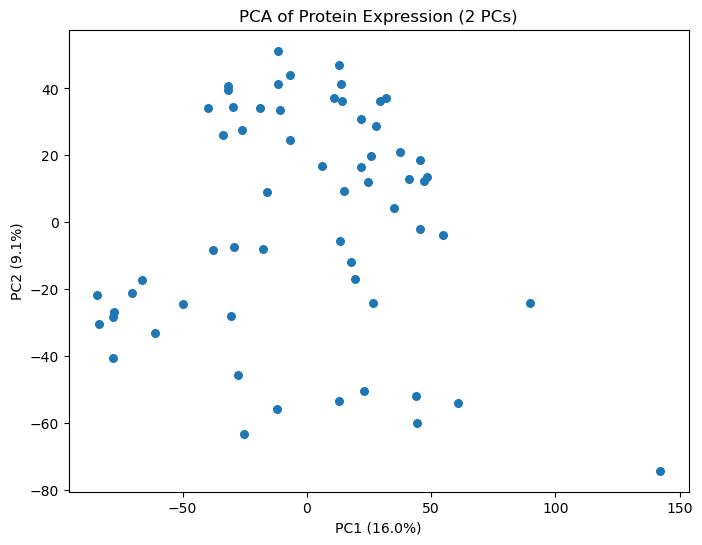

Explained variance ratio (first 10 PCs): [0.15995837 0.09128815]
Total variance explained by 2 PCs: 0.2512465161364456


In [11]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Transpose: samples x proteins

X = expr_avg.T
X.columns = X.columns.astype(str)

# Initialize PCA
pca = PCA(n_components=2, random_state=42)  # 2 components for visualization

# Fit + transform
X_pca = pca.fit_transform(X)

# Convert to DataFrame for plotting
pca_df = pd.DataFrame(X_pca, index=X.index, columns=["PC1", "PC2"])

# Quick scatter plot
plt.figure(figsize=(8,6))
plt.scatter(pca_df["PC1"], pca_df["PC2"], s=30)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("PCA of Protein Expression (2 PCs)")
plt.show()

# Optional: variance explained by first few PCs
print("Explained variance ratio (first 10 PCs):", pca.explained_variance_ratio_[:10])
print("Total variance explained by 2 PCs:", pca.explained_variance_ratio_[:2].sum())

In [65]:
X


Protein_ID,GLYG,AL1L2,FUBP3,SNX12,ARGAL,SBP1,AEBP1,EHD1,DYHC1,TBB3,...,SOSB2,RPP21,MMS22,SUPT3,UBP22,DC2I2,CLK2,ZBT45,BUB1,FLVC1
B67_1,16.220209,18.554141,18.128644,17.580392,16.583983,19.876242,21.923891,18.204906,21.201932,22.703762,...,10.023889,10.499738,9.534020,10.413540,11.148926,11.829904,9.576864,10.067999,9.794566,11.261999
CRC0_2,14.841091,10.875110,18.174225,17.626836,16.539288,19.592590,18.097865,17.585432,21.449037,22.758960,...,10.351045,10.885590,10.375298,10.511219,9.785690,10.239352,9.056454,9.810200,9.877864,10.060003
CRC4_P1,13.234044,10.979181,18.448345,17.585761,16.893022,20.464979,18.061909,17.262784,21.529929,23.014995,...,10.758871,9.984852,9.905234,10.902107,9.922493,11.355673,10.402801,9.062108,10.207724,11.512118
G119_P4,14.721562,13.721654,18.460856,17.627350,14.783786,19.814177,18.344357,18.156202,22.110178,23.115397,...,10.094936,9.405749,9.460485,9.577512,9.796217,10.407029,10.080095,9.560745,9.731128,10.132954
G133_P3,17.440474,10.509830,18.303016,17.279982,16.018865,19.284098,13.891723,17.359254,22.304714,22.643813,...,10.275149,9.719004,10.331867,11.318721,10.768167,9.308465,8.532574,7.893248,9.843726,9.817939
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
VCU_87,15.454160,12.161200,19.051196,17.101208,15.363089,18.736147,18.320248,16.661722,21.147207,22.822340,...,12.117607,10.568532,10.928903,9.844026,10.352261,9.973143,11.588392,9.168829,11.209947,9.500535
VCU_91,16.937019,10.783750,18.948674,17.028631,16.463887,19.291093,18.992654,18.442581,21.532602,22.483853,...,10.663104,11.341563,8.107156,10.274218,10.139847,9.369825,9.973755,10.144868,10.439813,9.578764
VCU_97,16.252202,11.393862,17.947440,17.546996,13.951576,16.445574,20.134782,18.357601,21.404208,22.934946,...,11.210419,10.080586,8.421529,9.902889,9.222608,8.557689,10.316522,9.412936,9.853178,9.538952
VCU_98,15.663278,12.563010,18.753252,16.930342,16.095388,17.689825,15.609372,16.488010,21.201731,22.295482,...,11.066314,11.246017,12.742998,9.283168,12.377213,9.920911,8.229430,9.386310,12.678572,10.086877


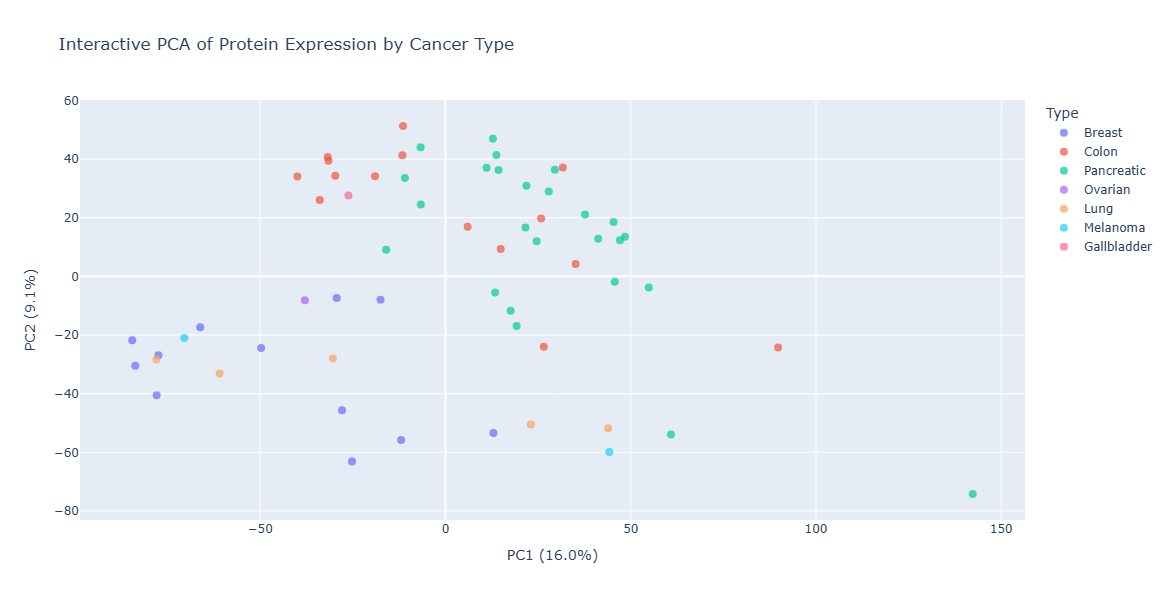

In [12]:
import plotly.express as px

# Initialize PCA
pca = PCA(n_components=20, random_state=42)  # 2 components for visualization

# Fit + transform
X_pca = pca.fit_transform(X)
X.columns = X.columns.astype(str)

# Convert to DataFrame for plotting
pca_df = pd.DataFrame(X_pca, index=X.index, columns=["PC1", "PC2", "PC3", "PC4", "PC5", "PC6", "PC7", "PC8", "PC9", "PC10",
                                                    "PC11", "PC12", "PC13", "PC14", "PC15", "PC16", "PC17", "PC18","PC19",
                                                    "PC20"])

# Make sure PCA DataFrame has sample identifiers as a column
pca_df["Sample_ID"] = pca_df.index  # Assuming index = original column names

# Merge PCA results with metadata
pca_df_merged = pca_df.merge(df_pca_md, on="Sample_ID")

# Interactive PCA plot
fig = px.scatter(
    pca_df_merged,
    x="PC1",
    y="PC2",
    color="Type",                  # color points by Type
    hover_data=["Sample_ID", "Type"],  # info shown on hover
    title="Interactive PCA of Protein Expression by Cancer Type",
    width=800,
    height=600
)

# Customize marker appearance
fig.update_traces(marker=dict(size=8, opacity=0.7))

# Label axes with explained variance
fig.update_layout(
    xaxis_title=f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)",
    yaxis_title=f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)"
)

fig.show()
fig.write_html("Nina_Normalized_PCA_120325.html")

In [13]:
expr_avg_filt = expr_avg.drop(columns="VCU_64")
expr_avg_filt = expr_avg_filt.drop(columns="VCU_23")

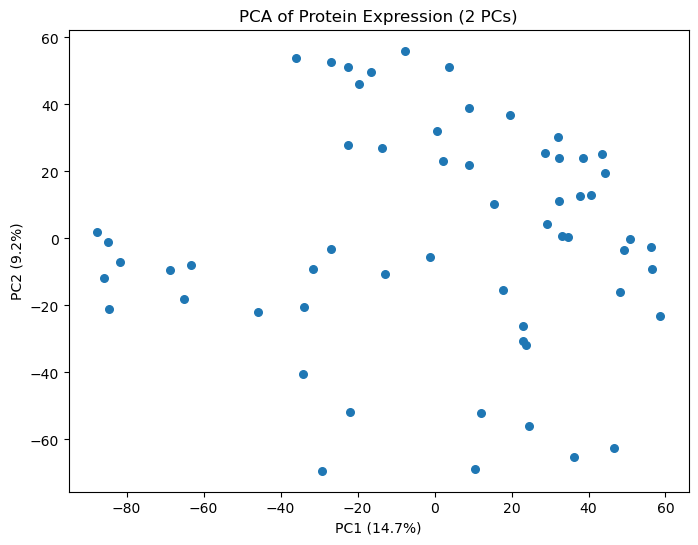

Explained variance ratio (first 10 PCs): [0.14651268 0.09227907 0.05781935]
Total variance explained by 2 PCs: 0.2387917452248332


In [14]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Transpose: samples x proteins

X = expr_avg_filt.T
X.columns = X.columns.astype(str)

# Initialize PCA
pca = PCA(n_components=3, random_state=42)  # 2 components for visualization

# Fit + transform
X_pca = pca.fit_transform(X)

# Convert to DataFrame for plotting
pca_df = pd.DataFrame(X_pca, index=X.index, columns=["PC1", "PC2", "PC3"])

# Quick scatter plot
plt.figure(figsize=(8,6))
plt.scatter(pca_df["PC1"], pca_df["PC2"], s=30)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("PCA of Protein Expression (2 PCs)")
plt.show()

# Optional: variance explained by first few PCs
print("Explained variance ratio (first 10 PCs):", pca.explained_variance_ratio_[:10])
print("Total variance explained by 2 PCs:", pca.explained_variance_ratio_[:2].sum())

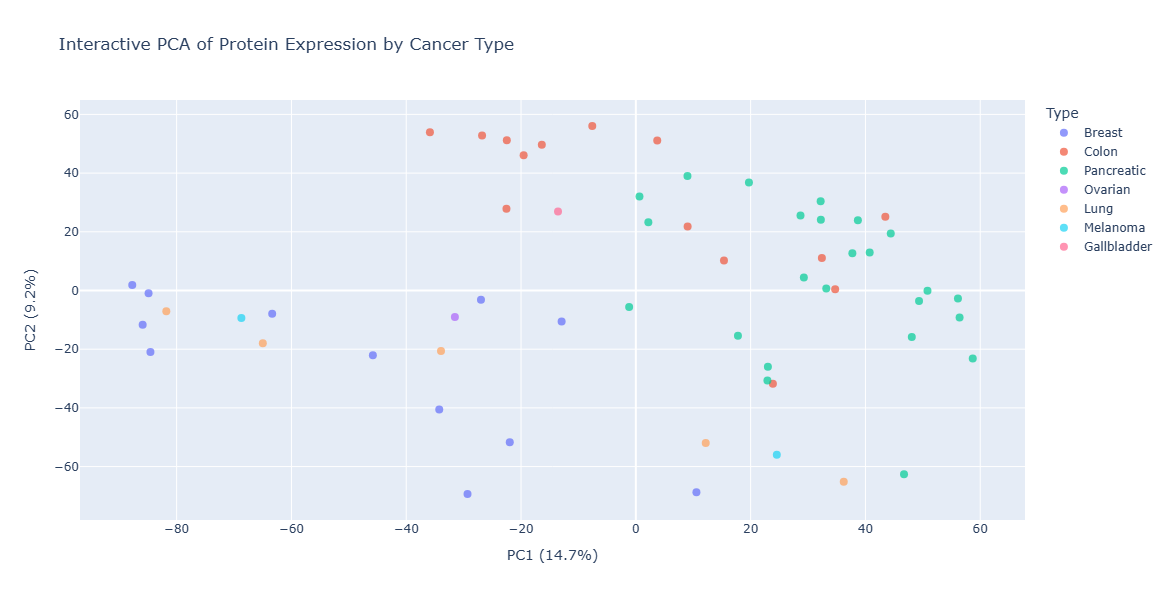

In [15]:
import plotly.express as px
# Initialize PCA
pca = PCA(n_components=20, random_state=42)  # 2 components for visualization

# Fit + transform
X_pca = pca.fit_transform(X)
X.columns = X.columns.astype(str)

# Convert to DataFrame for plotting
pca_df = pd.DataFrame(X_pca, index=X.index, columns=["PC1", "PC2", "PC3", "PC4", "PC5", "PC6", "PC7", "PC8", "PC9", "PC10",
                                                    "PC11", "PC12", "PC13", "PC14", "PC15", "PC16", "PC17", "PC18","PC19",
                                                    "PC20"])

# Make sure PCA DataFrame has sample identifiers as a column
pca_df["Sample_ID"] = pca_df.index  # Assuming index = original column names

# Merge PCA results with metadata
pca_df_merged = pca_df.merge(df_pca_md, on="Sample_ID")

# Interactive PCA plot
fig = px.scatter(
    pca_df_merged,
    x="PC1",
    y="PC2",
    color="Type",                  # color points by Type
    hover_data=["Sample_ID", "Type"],  # info shown on hover
    title="Interactive PCA of Protein Expression by Cancer Type",
    width=800,
    height=600
)

# Customize marker appearance
fig.update_traces(marker=dict(size=8, opacity=0.7))

# Label axes with explained variance
fig.update_layout(
    xaxis_title=f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)",
    yaxis_title=f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)"
)

fig.show()
fig.write_html("Nina_PCA_Normalized_DroppedOutliers_120325.html")

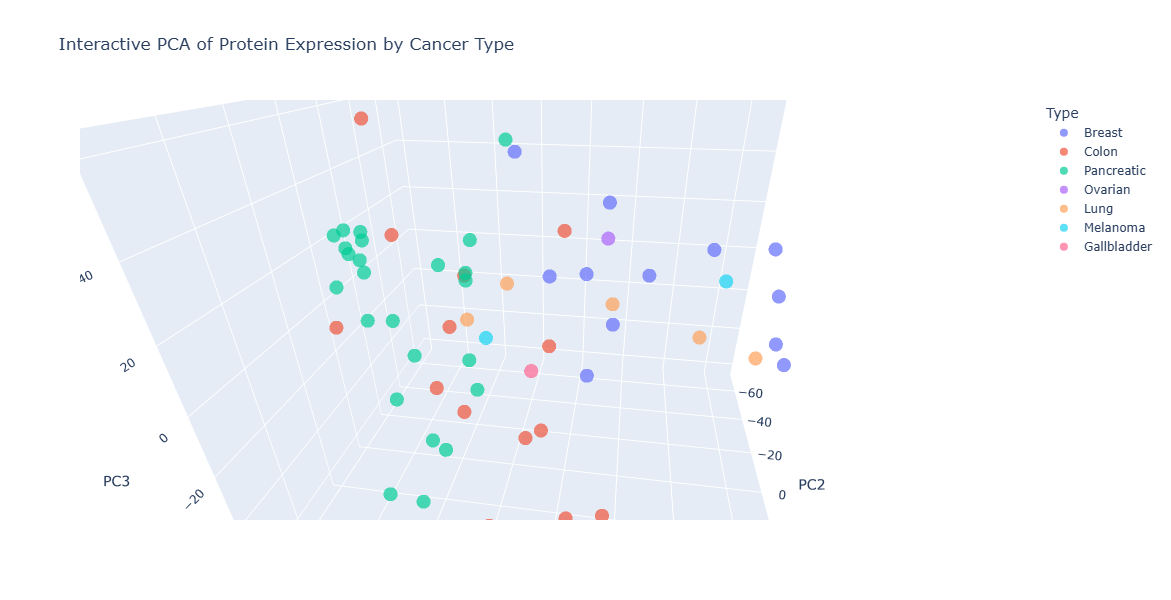

In [16]:
import plotly.express as px
# Initialize PCA
pca = PCA(n_components=20, random_state=42)  # 2 components for visualization

# Fit + transform
X_pca = pca.fit_transform(X)
X.columns = X.columns.astype(str)

# Convert to DataFrame for plotting
pca_df = pd.DataFrame(X_pca, index=X.index, columns=["PC1", "PC2", "PC3", "PC4", "PC5", "PC6", "PC7", "PC8", "PC9", "PC10",
                                                    "PC11", "PC12", "PC13", "PC14", "PC15", "PC16", "PC17", "PC18","PC19",
                                                    "PC20"])

# Make sure PCA DataFrame has sample identifiers as a column
pca_df["Sample_ID"] = pca_df.index  # Assuming index = original column names

# Merge PCA results with metadata
pca_df_merged = pca_df.merge(df_pca_md, on="Sample_ID")

# Interactive PCA plot
fig = px.scatter_3d(
    pca_df_merged,
    x="PC1",
    y="PC2",
    z="PC3",
    color="Type",                  # color points by Type
    hover_data=["Sample_ID", "Type"],  # info shown on hover
    title="Interactive PCA of Protein Expression by Cancer Type",
    width=800,
    height=600
)

# Customize marker appearance
fig.update_traces(marker=dict(size=8, opacity=0.7))

# Label axes with explained variance
fig.update_layout(
    xaxis_title=f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)",
    yaxis_title=f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)"
)

fig.show()
fig.write_html("Nina_PCA_3D_Normalized_DroppedOutliers_120325.html")

In [17]:
import plotly.express as px
# Initialize PCA
pca = PCA(n_components=20, random_state=42)  # 2 components for visualization

# Fit + transform
X_pca = pca.fit_transform(X)
X.columns = X.columns.astype(str)

# Convert to DataFrame for plotting
pca_df = pd.DataFrame(X_pca, index=X.index, columns=["PC1", "PC2", "PC3", "PC4", "PC5", "PC6", "PC7", "PC8", "PC9", "PC10",
                                                    "PC11", "PC12", "PC13", "PC14", "PC15", "PC16", "PC17", "PC18","PC19",
                                                    "PC20"])
pca_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20
B67_1,10.553472,-68.754278,37.716377,-23.973014,-33.761572,1.054243,9.781283,0.156252,-4.146427,15.702717,-15.351609,13.531019,15.996338,-8.605323,1.229633,-8.003989,0.320975,12.530313,29.028174,-5.102376
CRC0_2,43.466378,25.130435,6.129378,7.702515,-10.552748,17.499671,1.743580,21.978530,-14.751883,-15.757010,6.307556,14.784013,-12.550475,-1.423064,-1.397751,-1.897319,-5.402720,-0.638299,-7.046608,2.940214
CRC4_P1,34.724203,0.419310,25.650438,-58.288364,11.905062,9.652773,7.153847,1.541713,13.521071,-7.725327,-1.307033,-4.868704,-4.830154,-12.038740,-0.137587,1.036595,11.867011,18.234948,8.442565,-7.161173
G119_P4,48.074655,-15.846640,-15.297895,4.282185,0.576159,13.032319,-16.144792,23.250812,-2.149454,7.546894,-15.125047,0.496617,-9.808997,8.321723,-7.478376,4.419493,2.775889,8.319400,0.711136,-3.617505
G133_P3,0.632092,32.056113,-5.920765,10.736449,-42.572337,1.359359,-25.259562,14.867194,0.836484,-33.100060,1.731054,-58.368202,36.940727,22.422458,20.503456,-22.094237,-0.018346,39.406744,-5.666798,-0.089783
G186_P2,49.337832,-3.567957,14.629914,-2.106944,-2.196616,22.715137,10.232859,14.601708,-21.322358,-23.978346,13.821902,7.514417,-3.818956,0.237558,-1.818841,4.659374,4.082487,-7.263849,1.349933,-1.127860
G68_P3,46.720939,-62.629062,-12.417236,-16.718350,26.775562,22.123842,10.248612,-10.183452,20.460215,-24.453442,16.373266,-3.362821,14.800791,18.313856,-6.611394,1.424050,3.486339,15.710423,-0.678878,0.963037
H107_P1,3.728713,51.113795,8.724966,-12.474806,-4.297044,-18.048002,15.088941,-1.299192,-18.402375,5.857607,-16.782763,-0.374751,-0.507399,9.340625,-0.059409,9.471661,-3.513278,16.806750,-0.587917,12.939648
H30_2,-31.521609,-9.013786,24.662240,10.366296,-14.804864,-12.833280,-16.887799,20.142712,20.379375,24.539243,4.214897,24.401137,-11.753419,47.986645,44.087132,9.065529,-31.838478,-10.828083,-1.504292,18.766205
H32_2,-7.588987,56.048904,-29.945034,-28.398894,2.700622,-8.459921,10.901454,5.466321,8.665685,5.918844,-16.749300,-17.079848,-13.886127,5.799197,2.253876,-2.780201,-12.612999,13.221467,-19.248953,-19.756814


In [27]:
metadata.index.name = 'Index_Protein_ID'
metadata['Protein_ID'] = metadata.index
metadata

,Gene,Protein_ID
Index_Protein_ID,,
CP2D7,CYP2D7,CP2D7
PIOS1,PIGBOS1,PIOS1
MOTSC,MT-RNR1,MOTSC
CD3CH,CD300H,CD3CH
NBDY,NBDY,NBDY
...,...,...
YP002,PRO0461,YP002
YT001,PRO0628,YT001
YE014,PRO0255,YE014


In [28]:
import pandas as pd
import numpy as np

# Each column in expr_avg is a sample, each row is a protein
loadings = pd.DataFrame(
    pca.components_.T,                      # transpose: proteins × PCs
    index=expr_avg.index,                   # protein IDs
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)
loadings
loadings.index.name = 'Index_Protein_ID'

In [29]:
# Top 20 (by absolute contribution)
top_pc1 = loadings["PC1"].abs().sort_values(ascending=False).head(20)
top_pc1_df = loadings.loc[top_pc1.index, ["PC1"]]
top_pc1_df
top_pc1_df = top_pc1_df.merge(
    metadata,
    left_index=True,
    right_index=True,
    how="left"
)
top_pc1_df.to_csv("Nina_Unsupervised_PC1_Loadings_120325.tsv", sep="\t", index=False)
top_pc1_df


,PC1,Gene,Protein_ID
Index_Protein_ID,,,
AGR2,0.065027,AGR2,AGR2
AGR3,0.058775,AGR3,AGR3
B2L15,0.055856,BCL2L15,B2L15
PIGR,0.051153,PIGR,PIGR
AK1BA,0.051056,AKR1B10,AK1BA
MUC5A,0.050992,MUC5AC,MUC5A
UCHL1,-0.049454,UCHL1,UCHL1
CATE,0.048697,CTSE,CATE
S100P,0.047385,S100P,S100P


In [30]:
top_pc2 = loadings["PC2"].abs().sort_values(ascending=False).head(20)
top_pc2_df = loadings.loc[top_pc2.index, ["PC2"]]
top_pc2_df
top_pc2_df = top_pc2_df.merge(
    metadata,
    left_index=True,
    right_index=True,
    how="left"
)
top_pc2_df.to_csv("Nina_Unsupervised_PC2_Loadings_120325.tsv", sep="\t", index=False)
top_pc2_df

,PC2,Gene,Protein_ID
Index_Protein_ID,,,
VILI,0.071419,VIL1,VILI
LEG4,0.069954,LGALS4,LEG4
HMCS2,0.069371,HMGCS2,HMCS2
CAD17,0.064706,CDH17,CAD17
UCHL1,-0.064157,UCHL1,UCHL1
MUC13,0.063201,MUC13,MUC13
AVIL,0.062091,AVIL,AVIL
FABPL,0.061668,FABP1,FABPL
AGR3,0.056800,AGR3,AGR3


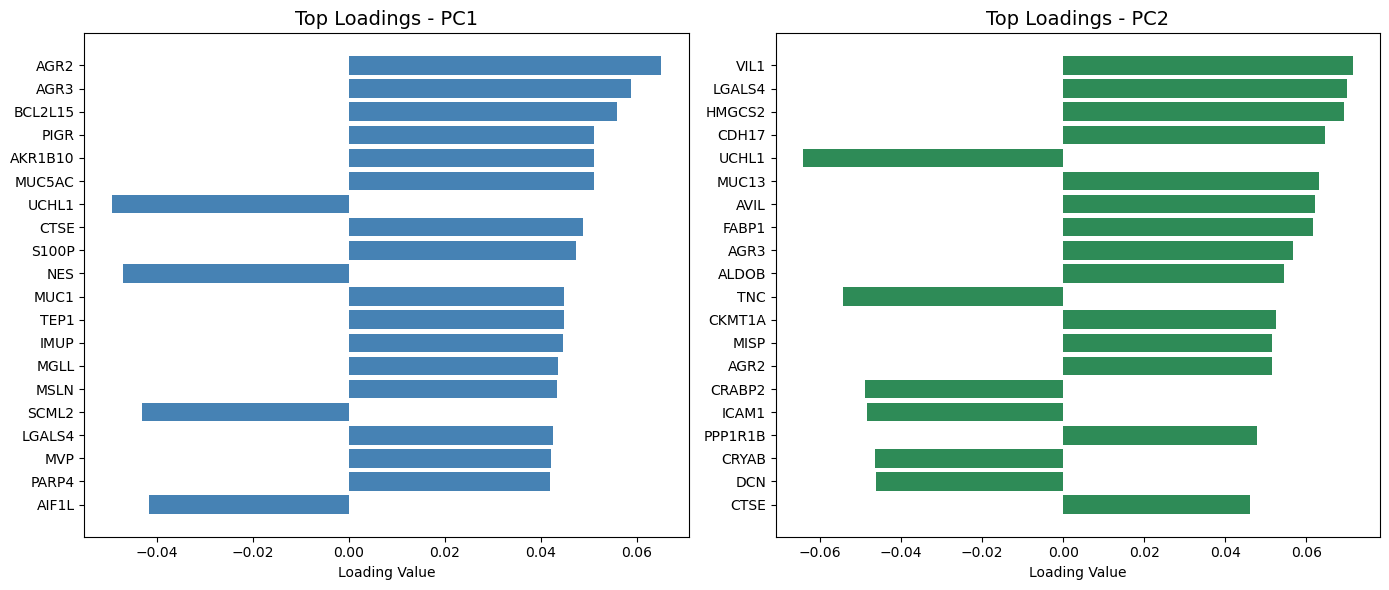

In [31]:
# --- Step 5: Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

# PC1 Barplot
axes[0].barh(top_pc1_df["Gene"].fillna(top_pc1_df["Protein_ID"]),
             top_pc1_df["PC1"], color="steelblue")
axes[0].set_title("Top Loadings - PC1", fontsize=14)
axes[0].invert_yaxis()
axes[0].set_xlabel("Loading Value")

# PC2 Barplot
axes[1].barh(top_pc2_df["Gene"].fillna(top_pc2_df["Protein_ID"]),
             top_pc2_df["PC2"], color="seagreen")
axes[1].set_title("Top Loadings - PC2", fontsize=14)
axes[1].invert_yaxis()
axes[1].set_xlabel("Loading Value")

plt.tight_layout()
plt.savefig("PCA_Loadings_PC1_PC2_120325.png", dpi=300, bbox_inches="tight")   # PNG (high-res)
plt.savefig("PCA_Loadings_PC1_PC2_120325.pdf", bbox_inches="tight") 
plt.show()

In [32]:
df_pca_md["Type"].value_counts()

Type
Pancreatic     25
Colon          15
Breast         12
Lung            5
Melanoma        2
Ovarian         1
Gallbladder     1
Name: count, dtype: int64

In [33]:
type_counts = df_pca_md["Type"].value_counts()
print("Sample counts per cancer type:")
print(type_counts)

# Step 2: Identify which types have fewer than 15 samples
types_to_drop = type_counts[type_counts < 5].index
print("\nCancer types to drop (fewer than 5 samples):")
print(types_to_drop.tolist())

# Step 3: Filter metadata to keep only samples with sufficient counts
metadata_filtered = df_pca_md[~df_pca_md["Type"].isin(types_to_drop)]
metadata_filtered

Sample counts per cancer type:
Type
Pancreatic     25
Colon          15
Breast         12
Lung            5
Melanoma        2
Ovarian         1
Gallbladder     1
Name: count, dtype: int64

Cancer types to drop (fewer than 5 samples):
['Melanoma', 'Ovarian', 'Gallbladder']


,Sample_ID,Type
0,B67_1,Breast
1,CRC0_2,Colon
2,CRC4_P1,Colon
3,G119_P4,Pancreatic
4,G133_P3,Pancreatic
5,G186_P2,Pancreatic
6,G68_P3,Pancreatic
7,H107_P1,Colon
9,H32_2,Colon
10,H36,Colon


In [34]:
expr_filtered = expr_avg[metadata_filtered["Sample_ID"].values]
expr_filtered

,B67_1,CRC0_2,CRC4_P1,G119_P4,G133_P3,G186_P2,G68_P3,H107_P1,H32_2,H36,...,VCU_80,VCU_81,VCU_82,VCU_83,VCU_84,VCU_86,VCU_91,VCU_97,VCU_98,VCU_99
Index_Protein_ID,,,,,,,,,,,,,,,,,,,,,
GLYG,16.220209,14.841091,13.234044,14.721562,17.440474,15.088466,14.620516,16.162366,16.282320,15.026581,...,15.113921,17.049423,16.055747,16.136451,16.229655,15.312461,16.937019,16.252202,15.663278,16.077025
AL1L2,18.554141,10.875110,10.979181,13.721654,10.509830,12.741621,12.710750,12.392301,13.471406,15.810326,...,10.987944,11.107325,9.865919,10.243614,10.167600,9.914101,10.783750,11.393862,12.563010,11.563866
FUBP3,18.128644,18.174225,18.448345,18.460856,18.303016,18.606960,17.647770,18.882367,18.852676,17.822583,...,18.200026,17.885560,18.619350,18.497048,18.112053,17.714733,18.948674,17.947440,18.753252,19.249336
SNX12,17.580392,17.626836,17.585761,17.627350,17.279982,18.049363,17.708738,17.768947,16.711155,17.159778,...,17.024262,17.114018,17.482742,17.472637,17.451917,16.769720,17.028631,17.546996,16.930342,17.225246
ARGAL,16.583983,16.539288,16.893022,14.783786,16.018865,15.612938,13.633424,17.206745,17.880679,15.469788,...,16.059471,15.494317,15.766555,16.895164,14.632292,15.361203,16.463887,13.951576,16.095388,16.602732
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DC2I2,11.829904,10.239352,11.355673,10.407029,9.308465,10.162904,9.896804,9.577133,8.858938,10.451205,...,9.191291,9.760704,10.131954,10.756126,10.412250,11.491303,9.369825,8.557689,9.920911,10.100084
CLK2,9.576864,9.056454,10.402801,10.080095,8.532574,9.904460,10.106918,9.130206,9.135487,9.010302,...,11.523860,9.977474,10.820430,10.548129,10.226019,11.887696,9.973755,10.316522,8.229430,10.012050
ZBT45,10.067999,9.810200,9.062108,9.560745,7.893248,10.360767,10.431450,9.158112,8.539686,8.622986,...,9.734249,9.760190,9.856778,9.744204,9.624945,10.274397,10.144868,9.412936,9.386310,10.081416


In [35]:
expr_avg_filt = expr_filtered.drop(columns="VCU_64")
expr_avg_filt = expr_avg_filt.drop(columns="VCU_23")
expr_avg_filt

,B67_1,CRC0_2,CRC4_P1,G119_P4,G133_P3,G186_P2,G68_P3,H107_P1,H32_2,H36,...,VCU_80,VCU_81,VCU_82,VCU_83,VCU_84,VCU_86,VCU_91,VCU_97,VCU_98,VCU_99
Index_Protein_ID,,,,,,,,,,,,,,,,,,,,,
GLYG,16.220209,14.841091,13.234044,14.721562,17.440474,15.088466,14.620516,16.162366,16.282320,15.026581,...,15.113921,17.049423,16.055747,16.136451,16.229655,15.312461,16.937019,16.252202,15.663278,16.077025
AL1L2,18.554141,10.875110,10.979181,13.721654,10.509830,12.741621,12.710750,12.392301,13.471406,15.810326,...,10.987944,11.107325,9.865919,10.243614,10.167600,9.914101,10.783750,11.393862,12.563010,11.563866
FUBP3,18.128644,18.174225,18.448345,18.460856,18.303016,18.606960,17.647770,18.882367,18.852676,17.822583,...,18.200026,17.885560,18.619350,18.497048,18.112053,17.714733,18.948674,17.947440,18.753252,19.249336
SNX12,17.580392,17.626836,17.585761,17.627350,17.279982,18.049363,17.708738,17.768947,16.711155,17.159778,...,17.024262,17.114018,17.482742,17.472637,17.451917,16.769720,17.028631,17.546996,16.930342,17.225246
ARGAL,16.583983,16.539288,16.893022,14.783786,16.018865,15.612938,13.633424,17.206745,17.880679,15.469788,...,16.059471,15.494317,15.766555,16.895164,14.632292,15.361203,16.463887,13.951576,16.095388,16.602732
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DC2I2,11.829904,10.239352,11.355673,10.407029,9.308465,10.162904,9.896804,9.577133,8.858938,10.451205,...,9.191291,9.760704,10.131954,10.756126,10.412250,11.491303,9.369825,8.557689,9.920911,10.100084
CLK2,9.576864,9.056454,10.402801,10.080095,8.532574,9.904460,10.106918,9.130206,9.135487,9.010302,...,11.523860,9.977474,10.820430,10.548129,10.226019,11.887696,9.973755,10.316522,8.229430,10.012050
ZBT45,10.067999,9.810200,9.062108,9.560745,7.893248,10.360767,10.431450,9.158112,8.539686,8.622986,...,9.734249,9.760190,9.856778,9.744204,9.624945,10.274397,10.144868,9.412936,9.386310,10.081416


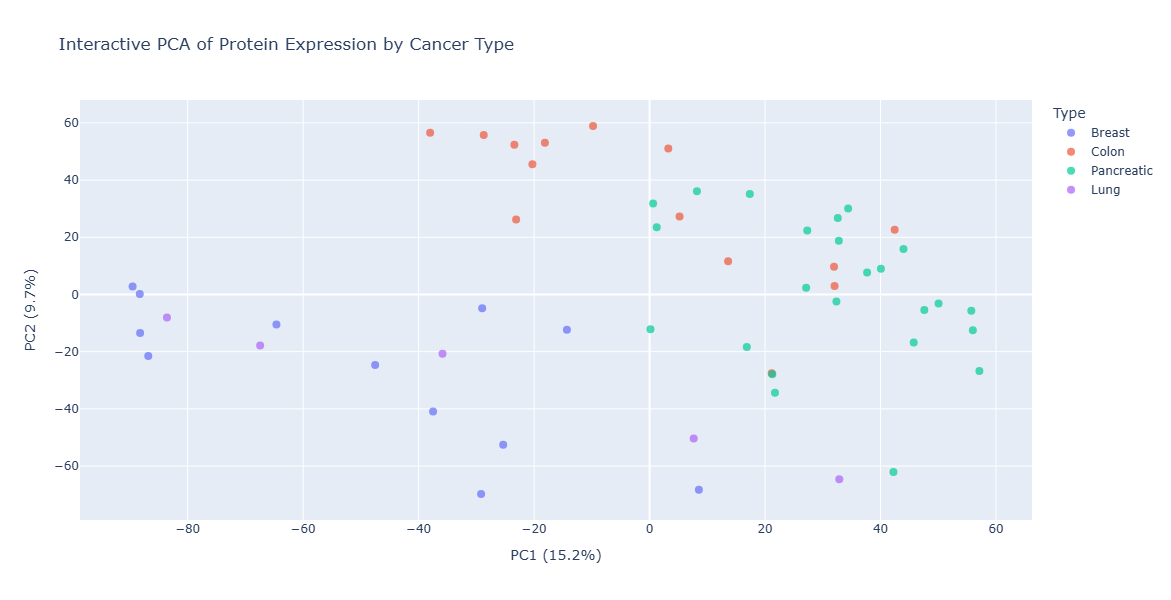

In [36]:
import plotly.express as px
# Initialize PCA
pca = PCA(n_components=20, random_state=42)  # 2 components for visualization

# Fit + transform
X = expr_avg_filt.T
X.columns = X.columns.astype(str)
X_pca = pca.fit_transform(X)


# Convert to DataFrame for plotting
pca_df = pd.DataFrame(X_pca, index=X.index, columns=["PC1", "PC2", "PC3", "PC4", "PC5", "PC6", "PC7", "PC8", "PC9", "PC10",
                                                    "PC11", "PC12", "PC13", "PC14", "PC15", "PC16", "PC17", "PC18","PC19",
                                                    "PC20"])

# Make sure PCA DataFrame has sample identifiers as a column
pca_df["Sample_ID"] = pca_df.index  # Assuming index = original column names

# Merge PCA results with metadata
pca_df_merged = pca_df.merge(df_pca_md, on="Sample_ID")

# Interactive PCA plot
fig = px.scatter(
    pca_df_merged,
    x="PC1",
    y="PC2",
    color="Type",                  # color points by Type
    hover_data=["Sample_ID", "Type"],  # info shown on hover
    title="Interactive PCA of Protein Expression by Cancer Type",
    width=800,
    height=600
)

# Customize marker appearance
fig.update_traces(marker=dict(size=8, opacity=0.7))

# Label axes with explained variance
fig.update_layout(
    xaxis_title=f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)",
    yaxis_title=f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)"
)

fig.show()
fig.write_html("Nina_PCA_Breast_Lung_Pancreas_Colon_DroppedOutliers_120325.html")

In [37]:
metadata_filtered

,Sample_ID,Type
0,B67_1,Breast
1,CRC0_2,Colon
2,CRC4_P1,Colon
3,G119_P4,Pancreatic
4,G133_P3,Pancreatic
5,G186_P2,Pancreatic
6,G68_P3,Pancreatic
7,H107_P1,Colon
9,H32_2,Colon
10,H36,Colon


In [39]:
metadata_avg = metadata_filtered[['Sample_ID', 'Type']].drop_duplicates().reset_index(drop=True)
metadata_avg

,Sample_ID,Type
0,B67_1,Breast
1,CRC0_2,Colon
2,CRC4_P1,Colon
3,G119_P4,Pancreatic
4,G133_P3,Pancreatic
5,G186_P2,Pancreatic
6,G68_P3,Pancreatic
7,H107_P1,Colon
8,H32_2,Colon
9,H36,Colon


In [40]:
metadata_avg = metadata_avg[metadata_avg['Sample_ID'] != 'VCU_64']
metadata_avg = metadata_avg[metadata_avg['Sample_ID'] != 'VCU_23']
metadata_avg

,Sample_ID,Type
0,B67_1,Breast
1,CRC0_2,Colon
2,CRC4_P1,Colon
3,G119_P4,Pancreatic
4,G133_P3,Pancreatic
5,G186_P2,Pancreatic
6,G68_P3,Pancreatic
7,H107_P1,Colon
8,H32_2,Colon
9,H36,Colon


In [41]:
# Set metadata index to match expression matrix
metadata_avg_indexed = metadata_avg.set_index('Sample_ID').loc[X.index]

# Confirm lengths match
print(len(X), len(metadata_avg))

metadata_avg_indexed

55 55


,Type
B67_1,Breast
CRC0_2,Colon
CRC4_P1,Colon
G119_P4,Pancreatic
G133_P3,Pancreatic
G186_P2,Pancreatic
G68_P3,Pancreatic
H107_P1,Colon
H32_2,Colon
H36,Colon


In [42]:
metadata_avg_indexed = metadata_avg.set_index('Sample_ID')
metadata_avg_indexed

,Type
Sample_ID,
B67_1,Breast
CRC0_2,Colon
CRC4_P1,Colon
G119_P4,Pancreatic
G133_P3,Pancreatic
G186_P2,Pancreatic
G68_P3,Pancreatic
H107_P1,Colon
H32_2,Colon


In [43]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelBinarizer
from sklearn.cross_decomposition import PLSRegression

# Features: samples x proteins (transpose your imputed expression)
X = expr_avg_filt.T  # samples x proteins
X.columns = X.columns.astype(str)
# Target: sample types
y = metadata_avg.set_index('Sample_ID')['Type']

# Encode target as one-hot
lb = LabelBinarizer()
Y_encoded = lb.fit_transform(y)
print("Classes:", lb.classes_)

Classes: ['Breast' 'Colon' 'Lung' 'Pancreatic']


In [47]:
pls = PLSRegression(n_components=2)
pls.fit(X, Y_encoded)

# Project samples into PLS latent space
X_scores = pls.x_scores_


              PLS1       PLS2 Sample_ID        Type
B67_1    -7.039152 -24.986480     B67_1      Breast
CRC0_2   27.288304   9.912020    CRC0_2       Colon
CRC4_P1  17.677356  24.389688   CRC4_P1       Colon
G119_P4  32.797755 -13.242890   G119_P4  Pancreatic
G133_P3   9.741687   7.905531   G133_P3  Pancreatic


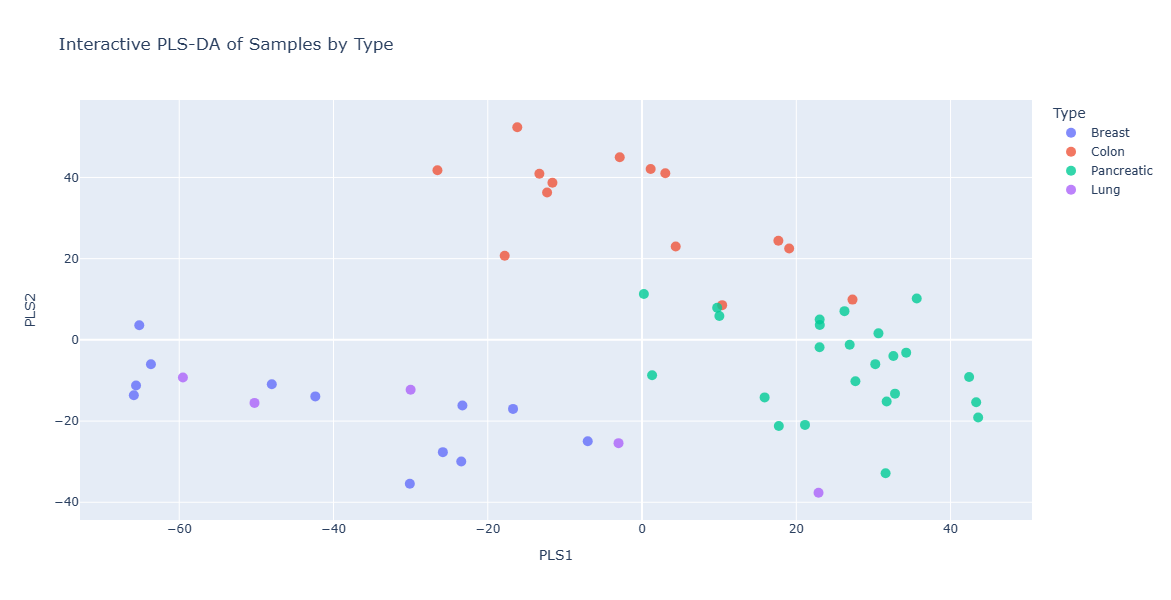

In [48]:
metadata_avg_indexed['Sample_ID'] = metadata_avg_indexed.index

df_scores = pd.DataFrame(
    X_scores,
    columns=['PLS1','PLS2'],
    index=X.index
)

# Add Sample_ID and Type from metadata
df_scores['Sample_ID'] = metadata_avg_indexed['Sample_ID']
df_scores['Type'] = metadata_avg_indexed['Type']

print(df_scores.head())


import plotly.express as px

fig = px.scatter(
    df_scores,
    x='PLS1',
    y='PLS2',
    color='Type',
    hover_data=['Sample_ID','Type'],
    title='Interactive PLS-DA of Samples by Type',
    width=800,
    height=600
)
fig.update_traces(marker=dict(size=10, opacity=0.8))
fig.show()
fig.write_html("PLSDA_2D_Plot_byType_PC1_PC2_120325.html")

In [49]:
pls = PLSRegression(n_components=3)
pls.fit(X, Y_encoded)

# Project samples into PLS latent space
X_scores = pls.x_scores_


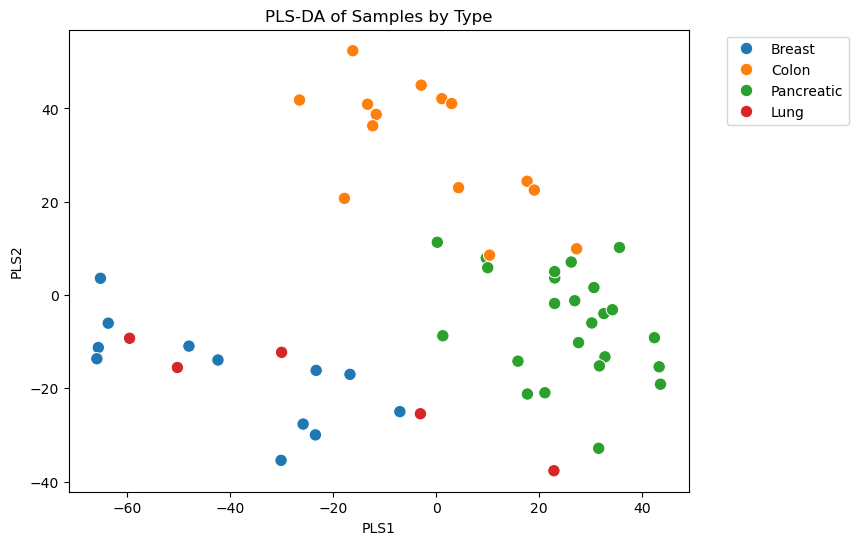

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_scores[:,0],
    y=X_scores[:,1],
    hue=y,
    palette='tab10',
    s=80
)
plt.xlabel("PLS1")
plt.ylabel("PLS2")
plt.title("PLS-DA of Samples by Type")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

              PLS1       PLS2       PLS3 Sample_ID        Type
B67_1    -7.039152 -24.986480  -1.945683     B67_1      Breast
CRC0_2   27.288304   9.912020   1.919433    CRC0_2       Colon
CRC4_P1  17.677356  24.389688 -15.437357   CRC4_P1       Colon
G119_P4  32.797755 -13.242890  -7.989242   G119_P4  Pancreatic
G133_P3   9.741687   7.905531  18.769818   G133_P3  Pancreatic


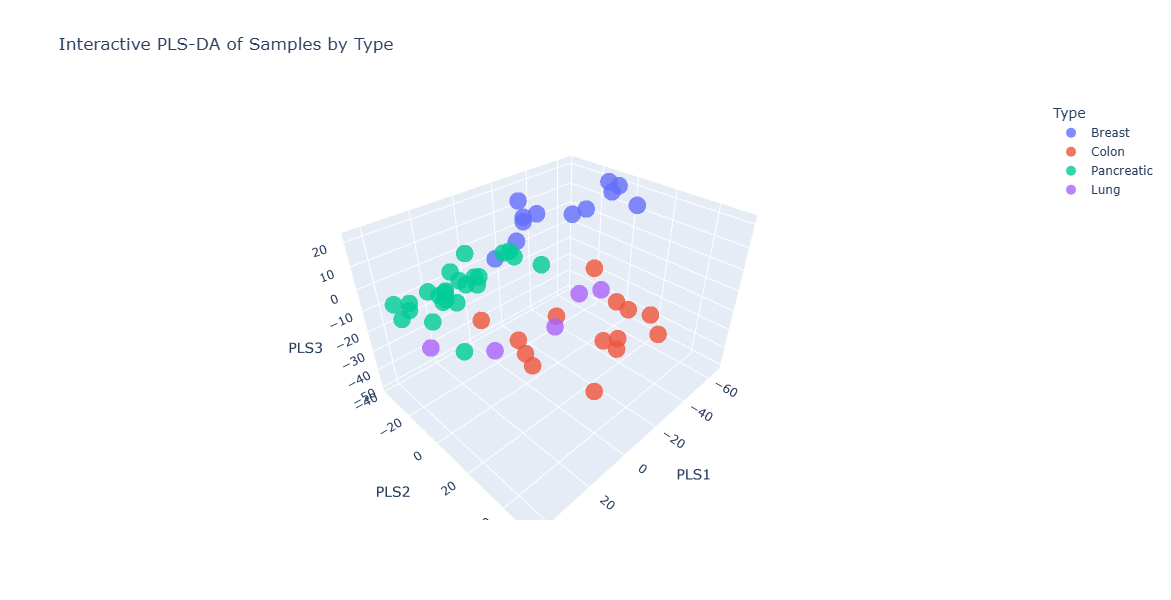

In [51]:
metadata_avg_indexed['Sample_ID'] = metadata_avg_indexed.index

df_scores = pd.DataFrame(
    X_scores,
    columns=['PLS1','PLS2', 'PLS3'],
    index=X.index
)

# Add Sample_ID and Type from metadata
df_scores['Sample_ID'] = metadata_avg_indexed['Sample_ID']
df_scores['Type'] = metadata_avg_indexed['Type']

print(df_scores.head())


import plotly.express as px

fig = px.scatter_3d(
    df_scores,
    x='PLS1',
    y='PLS2',
    z='PLS3',
    color='Type',
    hover_data=['Sample_ID','Type'],
    title='Interactive PLS-DA of Samples by Type',
    width=800,
    height=600
)
fig.update_traces(marker=dict(size=10, opacity=0.8))
fig.show()
fig.write_html("PLSDA_3D_Plot_byType_PC1_PC2_PC3_120325.html")

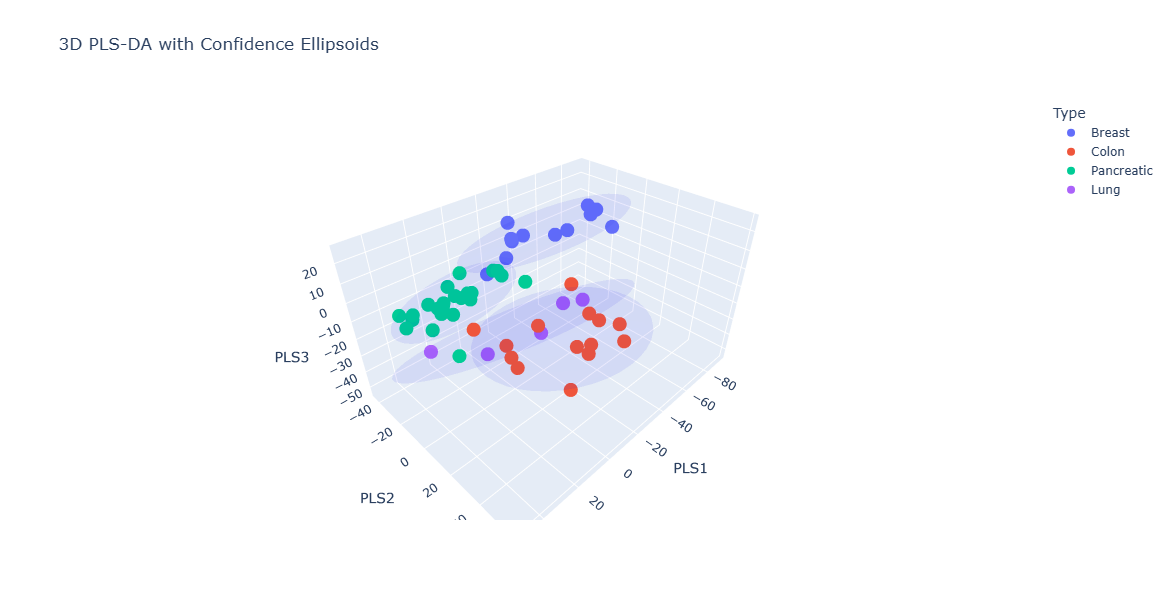

In [52]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px

# --- Your existing PLS-DA scatter ---
fig = px.scatter_3d(
    df_scores,
    x='PLS1', y='PLS2', z='PLS3',
    color='Type',
    hover_data=['Sample_ID', 'Type'],
    title='3D PLS-DA with Confidence Ellipsoids',
    width=800,
    height=600
)

# --- Function to add 3D ellipsoid for each group ---
def add_ellipsoid(fig, data, n_std=2.0, color='rgba(100,100,100,0.2)'):
    # Compute mean and covariance
    mean = np.mean(data, axis=0)
    cov = np.cov(data, rowvar=False)
    
    # Eigen-decomposition
    eigvals, eigvecs = np.linalg.eigh(cov)
    
    # Radii scaled by desired confidence level (n_std ~ standard deviations)
    radii = n_std * np.sqrt(eigvals)
    
    # Create a grid of points for the ellipsoid
    u = np.linspace(0, 2 * np.pi, 40)
    v = np.linspace(0, np.pi, 20)
    x = radii[0] * np.outer(np.cos(u), np.sin(v))
    y = radii[1] * np.outer(np.sin(u), np.sin(v))
    z = radii[2] * np.outer(np.ones_like(u), np.cos(v))
    
    # Rotate and translate the ellipsoid
    ellipsoid = np.dot(np.column_stack((x.flatten(), y.flatten(), z.flatten())), eigvecs.T)
    x_ell, y_ell, z_ell = ellipsoid[:, 0] + mean[0], ellipsoid[:, 1] + mean[1], ellipsoid[:, 2] + mean[2]
    x_ell = x_ell.reshape(x.shape)
    y_ell = y_ell.reshape(y.shape)
    z_ell = z_ell.reshape(z.shape)
    
    # Add to figure
    fig.add_trace(go.Surface(
        x=x_ell, y=y_ell, z=z_ell,
        opacity=0.2,
        showscale=False,
        surfacecolor=np.zeros_like(x_ell),
        colorscale=[[0, color], [1, color]],
        hoverinfo='skip'
    ))

# --- Add ellipsoids for each group ---
for group, group_df in df_scores.groupby('Type'):
    add_ellipsoid(fig, group_df[['PLS1', 'PLS2', 'PLS3']].values, color='rgba(0,0,255,0.2)')

# Customize markers
#fig.update_traces(marker=dict(size=6, opacity=0.8))
fig.show()


/home/woodslab/abarber18/.local/lib/python3.9/site-packages/scipy/spatial/distance.py:1035: RuntimeWarning:

invalid value encountered in sqrt



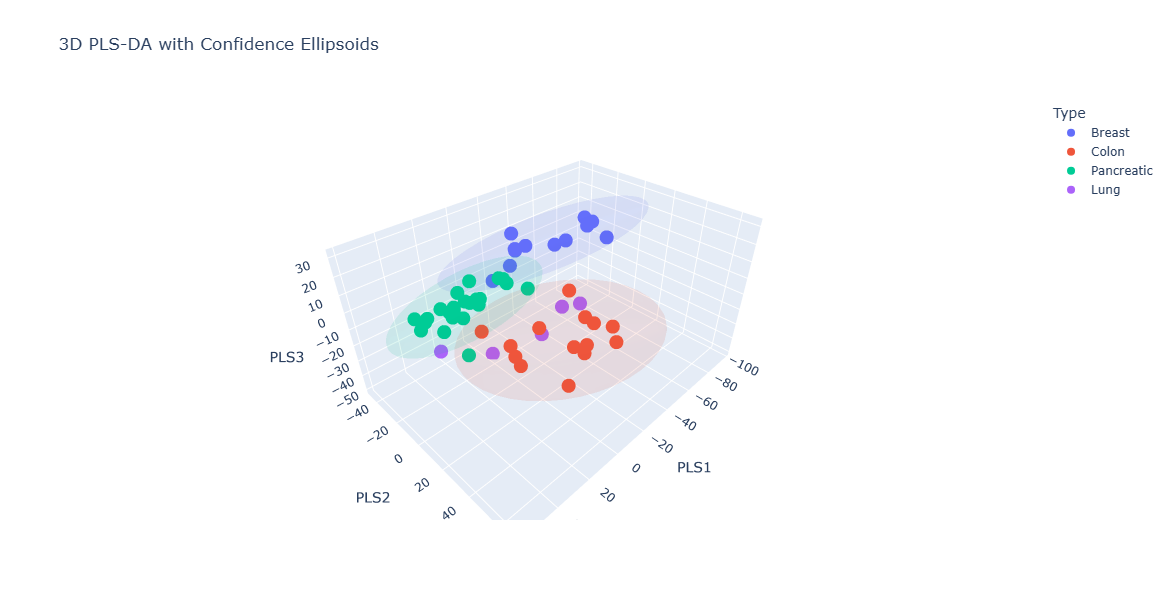

In [53]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px

# --- Your existing PLS-DA scatter ---
fig = px.scatter_3d(
    df_scores,
    x='PLS1', y='PLS2', z='PLS3',
    color='Type',
    hover_data=['Sample_ID', 'Type'],
    title='3D PLS-DA with Confidence Ellipsoids',
    width=800,
    height=600
)

# --- Extract the color mapping from the Plotly Express figure ---
# px automatically assigns a color per group; we can grab them:
color_map = {
    trace.name: trace.marker.color
    for trace in fig.data if hasattr(trace, 'name') and hasattr(trace.marker, 'color')
}

# --- Function to convert to RGBA with transparency ---
def to_rgba(hex_color, alpha=0.2):
    import matplotlib.colors as mcolors
    rgb = mcolors.to_rgb(hex_color)
    return f'rgba({int(rgb[0]*255)}, {int(rgb[1]*255)}, {int(rgb[2]*255)}, {alpha})'

import numpy as np
from scipy.spatial.distance import mahalanobis

def add_bootstrap_ellipsoid(fig, data, alpha=0.05, n_boot=2000, color='rgba(100,100,100,0.2)'):
    """
    Adds a 95% bootstrap ellipsoid for a small-sample group.
    
    Parameters
    ----------
    fig : plotly.graph_objects.Figure
        Plotly 3D figure to add the ellipsoid to.
    data : np.ndarray
        (n, p) array of PLS scores for the group.
    alpha : float
        Significance level (0.05 for 95% region).
    n_boot : int
        Number of bootstrap resamples.
    color : str
        RGBA color for ellipsoid surface.
    """
    n, p = data.shape
    mean = np.mean(data, axis=0)
    cov = np.cov(data, rowvar=False)
    eigvals, eigvecs = np.linalg.eigh(cov)

    # --- Bootstrap scaling factor ---
    # Compute bootstrap distribution of Mahalanobis distances
    mahal_dists = []
    for _ in range(n_boot):
        boot_sample = data[np.random.choice(n, n, replace=True), :]
        boot_mean = np.mean(boot_sample, axis=0)
        boot_cov = np.cov(boot_sample, rowvar=False)
        try:
            inv_cov = np.linalg.inv(boot_cov)
        except np.linalg.LinAlgError:
            continue  # skip singular cases
        # Mahalanobis distance of each point from boot mean
        d = [mahalanobis(x, boot_mean, inv_cov)**2 for x in boot_sample]
        mahal_dists.extend(d)

    # 95th percentile of squared Mahalanobis distance
    scale = np.sqrt(np.percentile(mahal_dists, 100 * (1 - alpha)))

    # --- Construct the ellipsoid ---
    radii = scale * np.sqrt(eigvals)
    u = np.linspace(0, 2 * np.pi, 40)
    v = np.linspace(0, np.pi, 20)
    x = radii[0] * np.outer(np.cos(u), np.sin(v))
    y = radii[1] * np.outer(np.sin(u), np.sin(v))
    z = radii[2] * np.outer(np.ones_like(u), np.cos(v))

    # Rotate and translate
    ellipsoid = np.dot(np.column_stack((x.flatten(), y.flatten(), z.flatten())), eigvecs.T)
    x_ell, y_ell, z_ell = (
        ellipsoid[:, 0].reshape(x.shape) + mean[0],
        ellipsoid[:, 1].reshape(y.shape) + mean[1],
        ellipsoid[:, 2].reshape(z.shape) + mean[2],
    )

    fig.add_trace(go.Surface(
        x=x_ell, y=y_ell, z=z_ell,
        opacity=0.25,
        showscale=False,
        surfacecolor=np.zeros_like(x_ell),
        colorscale=[[0, color], [1, color]],
        hoverinfo='skip'
    ))


# --- Add ellipsoids for each group, using the matching color ---
for group, group_df in df_scores.groupby('Type'):
    base_color = color_map.get(group, '#888888')
    rgba_color = to_rgba(base_color, alpha=0.25)
    add_bootstrap_ellipsoid(fig, group_df[['PLS1', 'PLS2', 'PLS3']].values,
                            alpha=0.05, n_boot=2000, color=rgba_color)


fig.show()


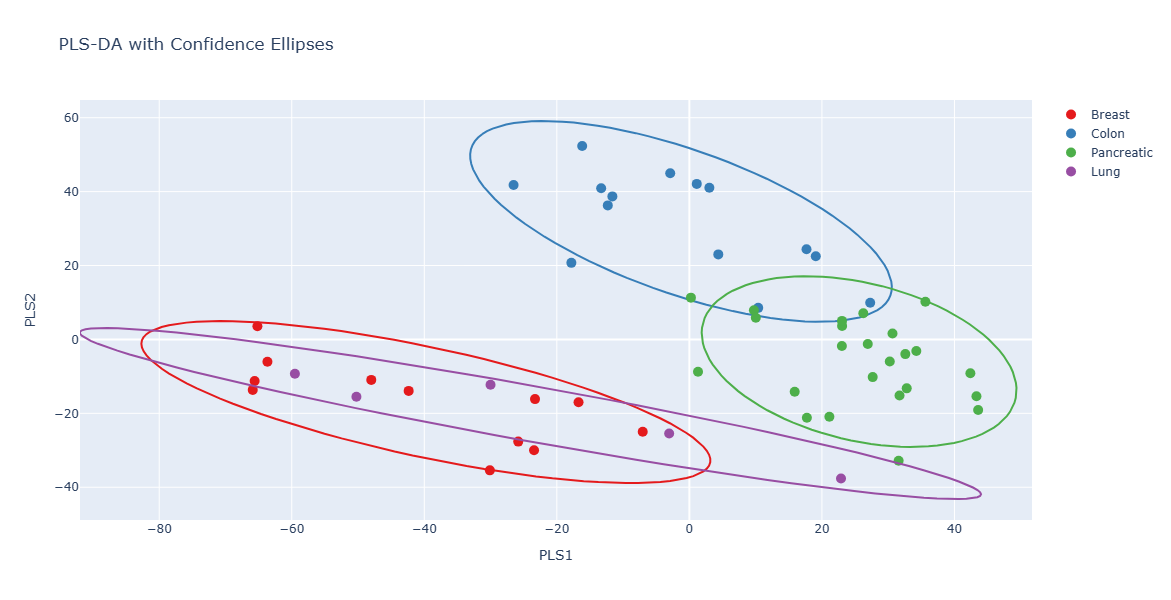

In [54]:
import numpy as np
import plotly.graph_objects as go

def make_ellipse(x, y, n_std=2.0, num_points=100):
    """
    Create an ellipse for the covariance of x and y points.
    n_std = number of standard deviations for the ellipse
    """
    cov = np.cov(x, y)
    mean_x = np.mean(x)
    mean_y = np.mean(y)

    # Eigen decomposition
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = eigvals.argsort()[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]

    # Parametric ellipse
    t = np.linspace(0, 2*np.pi, num_points)
    ellipse = np.array([np.cos(t), np.sin(t)])  # shape 2 x num_points

    # Scale by sqrt(eigenvalues) * n_std
    axes = n_std * np.sqrt(eigvals)
    ellipse = eigvecs @ np.diag(axes) @ ellipse

    # Translate to mean
    ellipse[0, :] += mean_x
    ellipse[1, :] += mean_y

    return ellipse[0, :], ellipse[1, :]

# -------------------------
# Create Plotly figure with points
fig = go.Figure()

types = df_scores['Type'].unique()
colors = px.colors.qualitative.Set1

for i, t in enumerate(types):
    subset = df_scores[df_scores['Type'] == t]
    
    # Add scatter points
    fig.add_trace(go.Scatter(
        x=subset['PLS1'],
        y=subset['PLS2'],
        mode='markers',
        name=t,
        marker=dict(size=10, color=colors[i % len(colors)]),
        hovertext=subset['Sample_ID']
    ))
    
    # Add ellipse
    ex, ey = make_ellipse(subset['PLS1'], subset['PLS2'], n_std=2)
    fig.add_trace(go.Scatter(
        x=ex, y=ey,
        mode='lines',
        line=dict(color=colors[i % len(colors)], width=2),
        name=f"{t} ellipse",
        showlegend=False
    ))

fig.update_layout(
    title="PLS-DA with Confidence Ellipses",
    xaxis_title="PLS1",
    yaxis_title="PLS2",
    width=800,
    height=600
)

fig.show()
fig.write_html("PLSDA-1-2_Interactive_Breast_Colon_Pancreatic_Lung_120325.html")

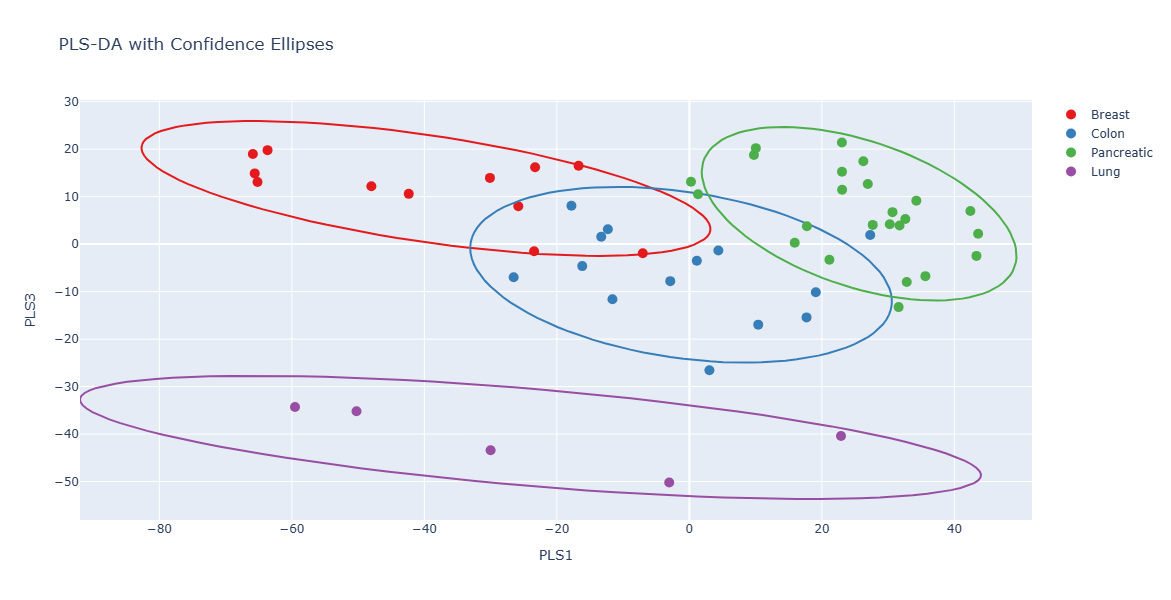

In [55]:
import numpy as np
import plotly.graph_objects as go

def make_ellipse(x, y, n_std=2.0, num_points=100):
    """
    Create an ellipse for the covariance of x and y points.
    n_std = number of standard deviations for the ellipse
    """
    cov = np.cov(x, y)
    mean_x = np.mean(x)
    mean_y = np.mean(y)

    # Eigen decomposition
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = eigvals.argsort()[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]

    # Parametric ellipse
    t = np.linspace(0, 2*np.pi, num_points)
    ellipse = np.array([np.cos(t), np.sin(t)])  # shape 2 x num_points

    # Scale by sqrt(eigenvalues) * n_std
    axes = n_std * np.sqrt(eigvals)
    ellipse = eigvecs @ np.diag(axes) @ ellipse

    # Translate to mean
    ellipse[0, :] += mean_x
    ellipse[1, :] += mean_y

    return ellipse[0, :], ellipse[1, :]

# -------------------------
# Create Plotly figure with points
fig = go.Figure()

types = df_scores['Type'].unique()
colors = px.colors.qualitative.Set1

for i, t in enumerate(types):
    subset = df_scores[df_scores['Type'] == t]
    
    # Add scatter points
    fig.add_trace(go.Scatter(
        x=subset['PLS1'],
        y=subset['PLS3'],
        mode='markers',
        name=t,
        marker=dict(size=10, color=colors[i % len(colors)]),
        hovertext=subset['Sample_ID']
    ))
    
    # Add ellipse
    ex, ey = make_ellipse(subset['PLS1'], subset['PLS3'], n_std=2)
    fig.add_trace(go.Scatter(
        x=ex, y=ey,
        mode='lines',
        line=dict(color=colors[i % len(colors)], width=2),
        name=f"{t} ellipse",
        showlegend=False
    ))

fig.update_layout(
    title="PLS-DA with Confidence Ellipses",
    xaxis_title="PLS1",
    yaxis_title="PLS3",
    width=800,
    height=600
)

fig.show()
fig.write_html("PLSDA-1-3_2D_Interactive_Breast_Colon_Pancreatic_Lung_120325.html")

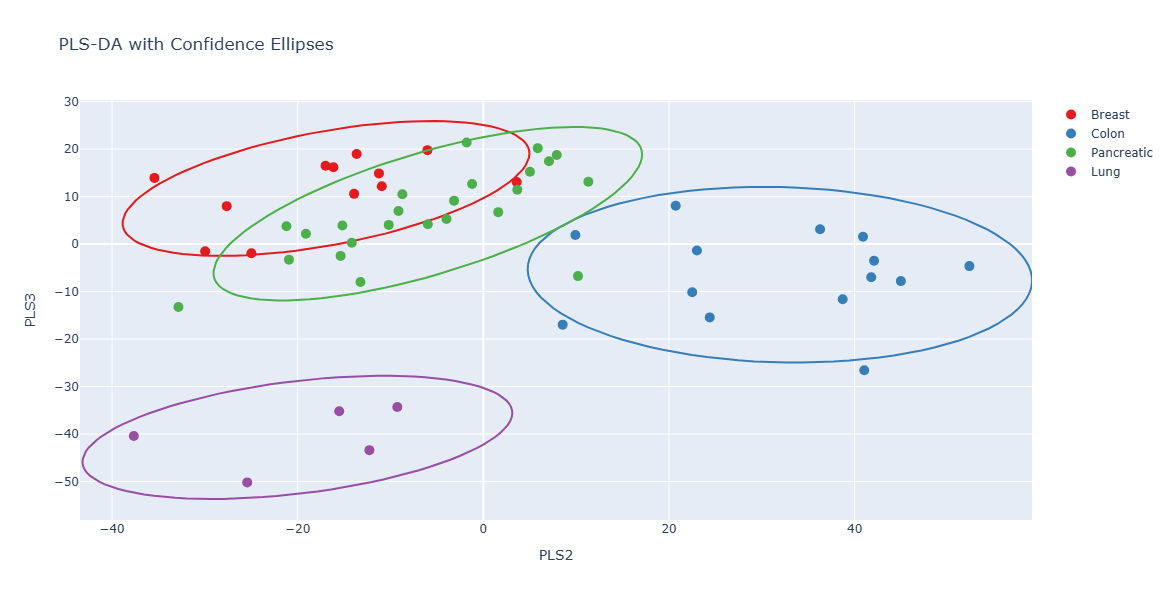

In [56]:
import numpy as np
import plotly.graph_objects as go

def make_ellipse(x, y, n_std=2.0, num_points=100):
    """
    Create an ellipse for the covariance of x and y points.
    n_std = number of standard deviations for the ellipse
    """
    cov = np.cov(x, y)
    mean_x = np.mean(x)
    mean_y = np.mean(y)

    # Eigen decomposition
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = eigvals.argsort()[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]

    # Parametric ellipse
    t = np.linspace(0, 2*np.pi, num_points)
    ellipse = np.array([np.cos(t), np.sin(t)])  # shape 2 x num_points

    # Scale by sqrt(eigenvalues) * n_std
    axes = n_std * np.sqrt(eigvals)
    ellipse = eigvecs @ np.diag(axes) @ ellipse

    # Translate to mean
    ellipse[0, :] += mean_x
    ellipse[1, :] += mean_y

    return ellipse[0, :], ellipse[1, :]

# -------------------------
# Create Plotly figure with points
fig = go.Figure()

types = df_scores['Type'].unique()
colors = px.colors.qualitative.Set1

for i, t in enumerate(types):
    subset = df_scores[df_scores['Type'] == t]
    
    # Add scatter points
    fig.add_trace(go.Scatter(
        x=subset['PLS2'],
        y=subset['PLS3'],
        mode='markers',
        name=t,
        marker=dict(size=10, color=colors[i % len(colors)]),
        hovertext=subset['Sample_ID']
    ))
    
    # Add ellipse
    ex, ey = make_ellipse(subset['PLS2'], subset['PLS3'], n_std=2)
    fig.add_trace(go.Scatter(
        x=ex, y=ey,
        mode='lines',
        line=dict(color=colors[i % len(colors)], width=2),
        name=f"{t} ellipse",
        showlegend=False
    ))

fig.update_layout(
    title="PLS-DA with Confidence Ellipses",
    xaxis_title="PLS2",
    yaxis_title="PLS3",
    width=800,
    height=600
)

fig.show()
fig.write_html("PLSDA-2-3_2D_Interactive_Breast_Colon_Pancreatic_Lung_120325.html")

In [59]:
# -------------------------
# 3️⃣ Extract protein loadings
# These indicate how strongly each protein contributes to the components
loadings = pd.DataFrame(
    pls.x_loadings_,
    index=expr_avg.index,  # Protein_IDs
    columns=[f'PLS{i+1}' for i in range(pls.x_loadings_.shape[1])]
)

# -------------------------
# 4️⃣ Rank proteins by importance
# Use absolute value of loadings (higher = more discriminative)
loadings['max_abs_loading'] = loadings.abs().max(axis=1)
top_proteins = loadings.sort_values('max_abs_loading', ascending=False)
top_proteins = top_proteins.merge(
    metadata,
    left_index=True,
    right_index=True,
    how="left"
)

# -------------------------
# 5️⃣ Inspect top proteins
top_n = 100
print(f"Top {top_n} proteins contributing to sample type separation:")
print(top_proteins.head(top_n))

# Optional: write to file
top_proteins.to_csv("PLSDA_top_proteins_Breast_Colon_Pancreatic_Lung_120325.txt", sep='\t')

Top 100 proteins contributing to sample type separation:
                      PLS1      PLS2      PLS3  max_abs_loading     Gene  \
Index_Protein_ID                                                           
CPEB4             0.005669  0.004089  0.041076         0.041076    CPEB4   
PICK1             0.006965  0.014530  0.038857         0.038857    PICK1   
EST1             -0.007196 -0.005922 -0.038766         0.038766     CES1   
RNF14            -0.005366  0.001527  0.037407         0.037407    RNF14   
TBC24            -0.007720  0.005088  0.037009         0.037009  TBC1D24   
...                    ...       ...       ...              ...      ...   
UFC1             -0.015751  0.008548  0.030704         0.030704     UFC1   
RGS3              0.012802  0.002394  0.030669         0.030669     RGS3   
SET               0.001138  0.003258 -0.030629         0.030629      SET   
TRI47             0.008089 -0.018995  0.030611         0.030611   TRIM47   
COG2              0.005047  0.0

In [58]:
metadata

,Gene,Protein_ID
Index_Protein_ID,,
CP2D7,CYP2D7,CP2D7
PIOS1,PIGBOS1,PIOS1
MOTSC,MT-RNR1,MOTSC
CD3CH,CD300H,CD3CH
NBDY,NBDY,NBDY
...,...,...
YP002,PRO0461,YP002
YT001,PRO0628,YT001
YE014,PRO0255,YE014


In [60]:
# --- Imports ---
import pandas as pd
import numpy as np
from scipy.stats import f_oneway
from statsmodels.stats.multitest import multipletests
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.patches as patches

# --- Step 0. Define clusters ---
all_clusters = ['Breast', 'Colon', 'Pancreatic', 'Lung']  

# --- Step 1. Collect sample IDs per cluster ---
cluster_samples = {
    c: metadata_avg_indexed.loc[metadata_avg_indexed["Type"] == c, "Sample_ID"].tolist()
    for c in all_clusters
}

# --- Step 2. Compute cluster averages ---
cluster_means = pd.DataFrame({
    c: expr_avg_filt[cluster_samples[c]].mean(axis=1)
    for c in all_clusters
})


# --- Step 3. Run ANOVA across all clusters ---
anova_results = []
for protein in expr_avg_filt.index:
    values = [expr_avg_filt.loc[protein, cluster_samples[c]] for c in all_clusters]
    f_val, p_val = f_oneway(*values)
    anova_results.append((protein, f_val, p_val))

anova_df = pd.DataFrame(anova_results, columns=["Protein_ID", "F_value", "p_value"])

# --- Step 4. Add multiple testing correction (Benjamini–Hochberg FDR) ---
anova_df["p_adj"] = multipletests(anova_df["p_value"], method="fdr_bh")[1]

# --- Step 5. Merge with cluster means and metadata ---
anova_df = anova_df.merge(cluster_means, left_on="Protein_ID", right_index=True)
anova_df = anova_df.merge(metadata[["Protein_ID", "Gene"]], on="Protein_ID", how="left")


anova_df



,Protein_ID,F_value,p_value,p_adj,Breast,Colon,Pancreatic,Lung,Gene
0,GLYG,3.489967,2.214926e-02,0.057207,15.466788,14.726600,15.942650,15.432717,GYG1
1,AL1L2,7.636206,2.607518e-04,0.002222,14.438920,12.661103,11.564934,14.698646,ALDH1L2
2,FUBP3,1.330421,2.747265e-01,0.367175,18.401964,18.516862,18.323507,18.731130,FUBP3
3,SNX12,0.229960,8.751047e-01,0.898158,17.245738,17.134870,17.259638,17.184875,SNX12
4,ARGAL,14.952536,4.147012e-07,0.000017,15.438213,16.598070,15.226845,12.217082,ARHGEF10L
...,...,...,...,...,...,...,...,...,...
7826,DC2I2,5.337843,2.826146e-03,0.012302,11.619905,10.519334,10.242884,10.064539,DYNC2I2
7827,CLK2,1.663347,1.865118e-01,0.275944,10.388329,9.515847,9.801226,9.734732,CLK2
7828,ZBT45,1.338732,2.721020e-01,0.364868,9.766437,9.389301,9.666047,9.397192,ZBTB45
7829,BUB1,8.046027,1.739625e-04,0.001616,12.495817,10.205061,10.917625,11.310922,BUB1


In [61]:
# Step 6: Calculate Log2FC
anova_df["Most_Expressed"] = anova_df[['Breast', 'Colon', 'Pancreatic', 'Lung']].idxmax(axis=1)
anova_df["Least_Expressed"] = anova_df[['Breast', 'Colon', 'Pancreatic', 'Lung']].idxmin(axis=1)
anova_df['Greatest_Log2FC'] = anova_df[['Breast', 'Colon', 'Pancreatic', 'Lung']].max(axis=1) - anova_df[['Breast', 'Colon', 'Pancreatic', 'Lung']].min(axis=1)
anova_df

,Protein_ID,F_value,p_value,p_adj,Breast,Colon,Pancreatic,Lung,Gene,Most_Expressed,Least_Expressed,Greatest_Log2FC
0,GLYG,3.489967,2.214926e-02,0.057207,15.466788,14.726600,15.942650,15.432717,GYG1,Pancreatic,Colon,1.216050
1,AL1L2,7.636206,2.607518e-04,0.002222,14.438920,12.661103,11.564934,14.698646,ALDH1L2,Lung,Pancreatic,3.133711
2,FUBP3,1.330421,2.747265e-01,0.367175,18.401964,18.516862,18.323507,18.731130,FUBP3,Lung,Pancreatic,0.407623
3,SNX12,0.229960,8.751047e-01,0.898158,17.245738,17.134870,17.259638,17.184875,SNX12,Pancreatic,Colon,0.124768
4,ARGAL,14.952536,4.147012e-07,0.000017,15.438213,16.598070,15.226845,12.217082,ARHGEF10L,Colon,Lung,4.380987
...,...,...,...,...,...,...,...,...,...,...,...,...
7826,DC2I2,5.337843,2.826146e-03,0.012302,11.619905,10.519334,10.242884,10.064539,DYNC2I2,Breast,Lung,1.555365
7827,CLK2,1.663347,1.865118e-01,0.275944,10.388329,9.515847,9.801226,9.734732,CLK2,Breast,Colon,0.872482
7828,ZBT45,1.338732,2.721020e-01,0.364868,9.766437,9.389301,9.666047,9.397192,ZBTB45,Breast,Colon,0.377136
7829,BUB1,8.046027,1.739625e-04,0.001616,12.495817,10.205061,10.917625,11.310922,BUB1,Breast,Colon,2.290756


In [62]:
# --- Step 7. Select top N proteins per defining cluster ---
top_n = 10
top_by_cluster = []
for c in all_clusters:
    sub = anova_df[anova_df["Most_Expressed"] == c].nsmallest(top_n, "p_adj")
    sub["Type"] = c
    top_by_cluster.append(sub)

top_genes_df = pd.concat(top_by_cluster)
top_genes_df = top_genes_df.drop_duplicates(subset="Gene")
top_genes_df = top_genes_df.sort_values("Type")
top_genes_df

,Protein_ID,F_value,p_value,p_adj,Breast,Colon,Pancreatic,Lung,Gene,Most_Expressed,Least_Expressed,Greatest_Log2FC,Type
2131,AIF1L,38.735226,3.441199e-13,2.186787e-10,15.211188,10.618451,10.324077,12.275571,AIF1L,Breast,Pancreatic,4.887111,Breast
1712,TRPS1,26.944789,1.390609e-10,3.889236e-08,18.186304,12.410591,12.856075,13.966010,TRPS1,Breast,Colon,5.775713,Breast
4274,HOME3,25.208068,3.840530e-10,9.524122e-08,14.617421,10.959676,11.492727,14.183861,HOMER3,Breast,Colon,3.657745,Breast
698,RABP2,24.666845,5.315220e-10,1.156208e-07,19.652900,12.769014,16.528211,16.070726,CRABP2,Breast,Colon,6.883886,Breast
1275,HDAC2,24.532978,5.763753e-10,1.207566e-07,16.841992,15.794945,14.916121,16.023643,HDAC2,Breast,Pancreatic,1.925871,Breast
5676,SCML2,23.975628,8.098347e-10,1.509956e-07,14.817906,11.839761,10.615789,13.482880,SCML2,Breast,Pancreatic,4.202117,Breast
1723,RABE1,22.736151,1.753919e-09,2.543508e-07,16.716262,15.324659,14.440463,15.464529,RABEP1,Breast,Pancreatic,2.275799,Breast
4900,ASAP3,22.654711,1.846792e-09,2.629496e-07,14.318231,10.419302,10.227649,11.927252,ASAP3,Breast,Pancreatic,4.090582,Breast
7094,AP2A,22.094424,2.641247e-09,3.547146e-07,13.609906,11.444674,10.613348,12.334041,TFAP2A,Breast,Pancreatic,2.996558,Breast
5103,SETMR,21.098099,5.053289e-09,6.183173e-07,14.474016,13.956908,11.156902,12.807150,SETMAR,Breast,Pancreatic,3.317115,Breast


/tmp/ipykernel_3394801/771496891.py:144: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



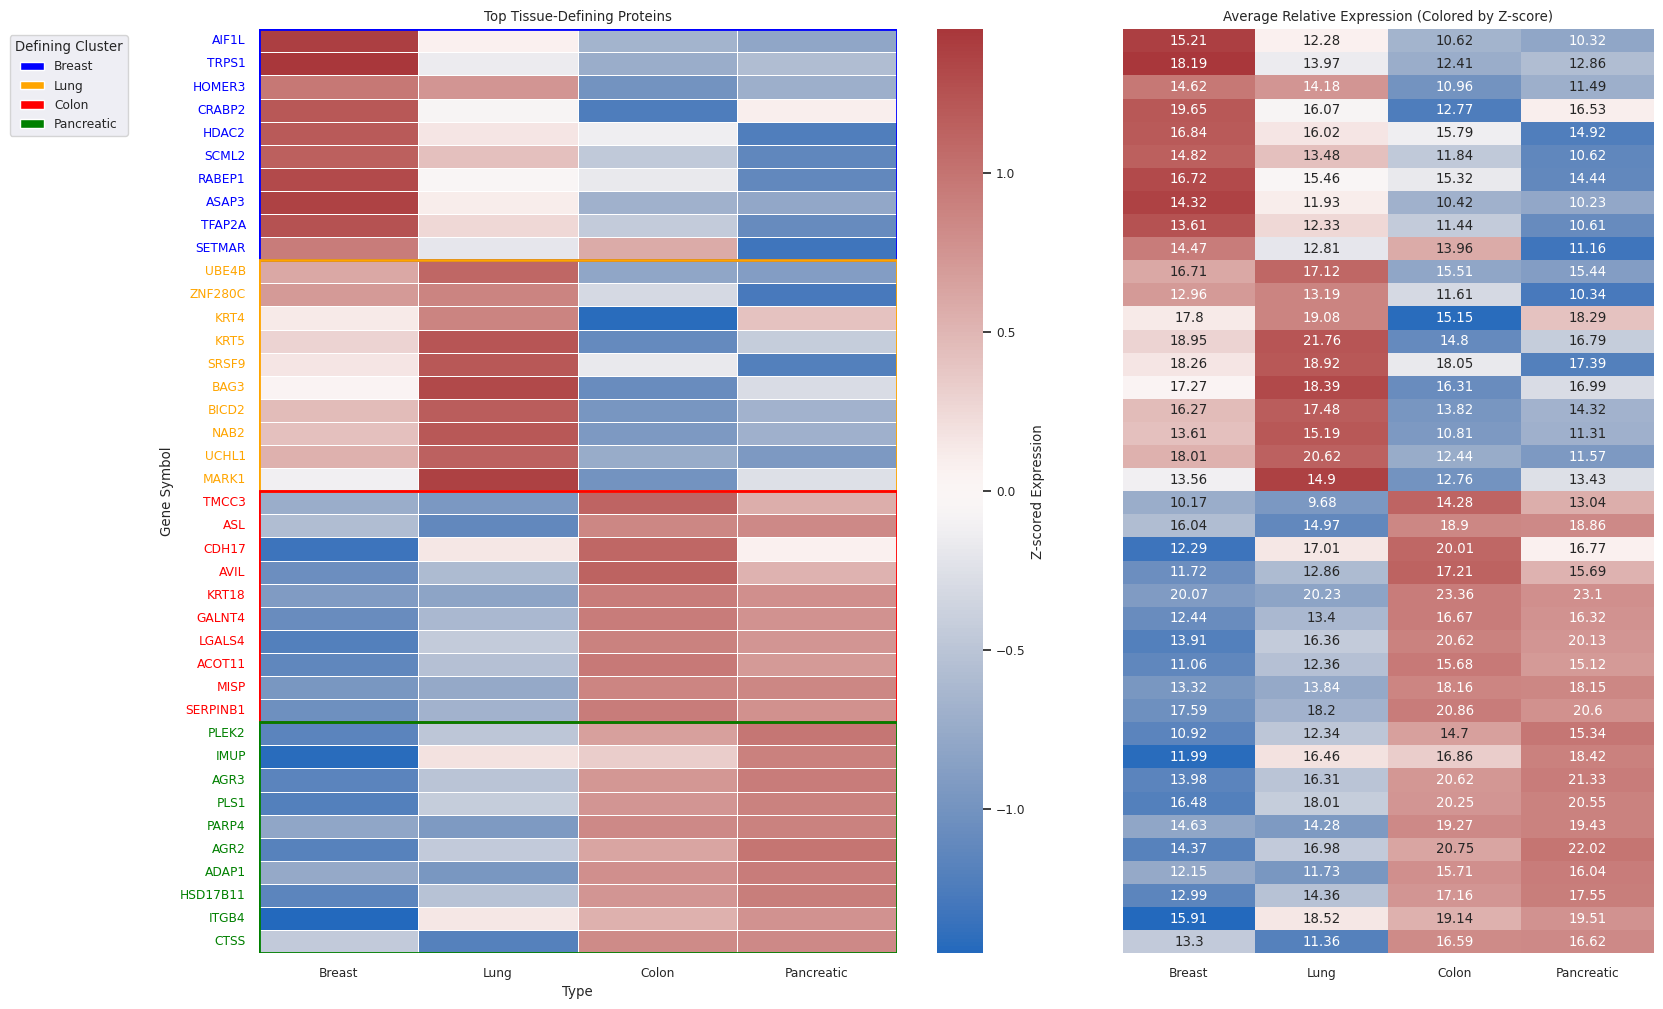

In [63]:
import pandas as pd
import numpy as np
from scipy.stats import f_oneway
from statsmodels.stats.multitest import multipletests
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.patches as patches

# --- Step 0. Define clusters ---
all_clusters = ['Breast', 'Lung', 'Colon', 'Pancreatic']  

# --- Step 1. Collect sample IDs per cluster ---
cluster_samples = {
    c: metadata_avg_indexed.loc[metadata_avg_indexed["Type"] == c, "Sample_ID"].tolist()
    for c in all_clusters
}

# --- Step 2. Compute cluster averages ---
cluster_means = pd.DataFrame({
    c: expr_avg_filt[cluster_samples[c]].mean(axis=1)
    for c in all_clusters
})


# --- Step 3. Run ANOVA across all clusters ---
anova_results = []
for protein in expr_avg_filt.index:
    values = [expr_avg_filt.loc[protein, cluster_samples[c]] for c in all_clusters]
    f_val, p_val = f_oneway(*values)
    anova_results.append((protein, f_val, p_val))

anova_df = pd.DataFrame(anova_results, columns=["Protein_ID", "F_value", "p_value"])

# --- Step 4. Add multiple testing correction (Benjamini–Hochberg FDR) ---
anova_df["p_adj"] = multipletests(anova_df["p_value"], method="fdr_bh")[1]

# --- Step 5. Merge with cluster means and metadata ---
anova_df = anova_df.merge(cluster_means, left_on="Protein_ID", right_index=True)
anova_df = anova_df.merge(metadata[["Protein_ID", "Gene"]], on="Protein_ID", how="left")

# Step 6: Calculate Log2FC
anova_df["Most_Expressed"] = anova_df[['Breast', 'Colon', 'Pancreatic', 'Lung']].idxmax(axis=1)
anova_df["Least_Expressed"] = anova_df[['Breast', 'Colon', 'Pancreatic', 'Lung']].idxmin(axis=1)
anova_df['Greatest_Log2FC'] = anova_df[['Breast', 'Colon', 'Pancreatic', 'Lung']].max(axis=1) - anova_df[['Breast', 'Colon', 'Pancreatic', 'Lung']].min(axis=1)

# --- Step 7. Select top N proteins per defining cluster ---
top_n = 10
top_by_cluster = []
for c in all_clusters:
    sub = anova_df[anova_df["Most_Expressed"] == c].nsmallest(top_n, "p_adj")
    sub["Type"] = c
    top_by_cluster.append(sub)

top_genes_df = pd.concat(top_by_cluster)
top_genes_df = top_genes_df.drop_duplicates(subset="Gene")
type_order = ['Breast', 'Lung', 'Colon', 'Pancreatic']
top_genes_df['Type'] = pd.Categorical(top_genes_df['Type'], categories=type_order, ordered=True)
top_genes_df = top_genes_df.sort_values('Type')

top_genes_df

# --- Step 8. Build heatmap data ---
heatmap_data = cluster_means.loc[top_genes_df["Protein_ID"], ['Breast', 'Lung', 'Colon', 'Pancreatic']]
heatmap_data.index = top_genes_df["Gene"]

# --- Step 9. Compute Z-scores across all clusters ---
heatmap_data_z = heatmap_data.sub(heatmap_data.mean(axis=1), axis=0).div(heatmap_data.std(axis=1), axis=0)

# --- Step 10. Define cluster colors ---
cluster_color_map = {'Breast': "blue", 'Lung': "orange", 'Colon': "red", 'Pancreatic': "green"}
row_colors = top_genes_df.set_index("Gene")["Type"].map(cluster_color_map)

# --- Step 11. Plot heatmap + expression table ---
sns.set(font_scale=0.8)
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(1, 2, width_ratios=[3, 2], wspace=0.1)

# Left: Z-scored heatmap
ax0 = fig.add_subplot(gs[0])
sns.heatmap(
    heatmap_data_z,
    cmap="vlag",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Z-scored Expression"},
    ax=ax0,
    yticklabels=True,
    xticklabels=['Breast', 'Lung', 'Colon', 'Pancreatic']
)
ax0.set_title("Top Tissue-Defining Proteins")
ax0.set_xlabel("Type")
ax0.set_ylabel("Gene Symbol")

# Color row labels by defining cluster
for ytick, gene in zip(ax0.get_yticklabels(), heatmap_data_z.index):
    cluster = top_genes_df.set_index("Gene").loc[gene, "Type"]
    ytick.set_color(cluster_color_map[cluster])

# --- Fix: Color expression table by Z-scores but show average values ---
# We re-use the color mapping from heatmap_data_z for coloring
ax1 = fig.add_subplot(gs[1])
sns.heatmap(
    heatmap_data_z,       # use Z-scores for coloring
    annot=heatmap_data.round(2),  # show actual average expression values
    fmt="",               # suppress scientific notation
    cmap="vlag",
    center=0,
    cbar=False,
    yticklabels=False,
    xticklabels=['Breast', 'Lung', 'Colon', 'Pancreatic'],
    ax=ax1
)
ax1.set_title("Average Relative Expression (Colored by Z-score)")
ax1.set_ylabel("")

# --- Step 12. Legend for defining clusters ---
handles = [Patch(facecolor=color, label=c) for c, color in cluster_color_map.items()]
ax0.legend(handles=handles, title="Defining Cluster", loc="upper left", bbox_to_anchor=(-0.4, 1))

# --- Step 13. Bounding boxes for cluster-defining genes (respect ordered tissue list) ---
type_order = ['Breast', 'Lung', 'Colon', 'Pancreatic']

for cluster in type_order:
    color = cluster_color_map[cluster]
    gene_indices = [
        i for i, gene in enumerate(heatmap_data_z.index)
        if top_genes_df.set_index("Gene").loc[gene, "Type"] == cluster
    ]
    if not gene_indices:
        continue
    y_start = min(gene_indices)
    y_end = max(gene_indices) + 1
    rect = patches.Rectangle(
        xy=(0, y_start),
        width=len(type_order),
        height=y_end - y_start,
        fill=False,
        edgecolor=color,
        linewidth=2
    )
    ax0.add_patch(rect)

plt.tight_layout()
plt.savefig("Cluster_Heatmap_ExpressionTable_wLung_padj_120325.png", dpi=300, bbox_inches="tight")
plt.savefig("Cluster_Heatmap_ExpressionTable_wLung_padj_120325.pdf", bbox_inches="tight")
plt.show()

/tmp/ipykernel_3394801/1030725240.py:144: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



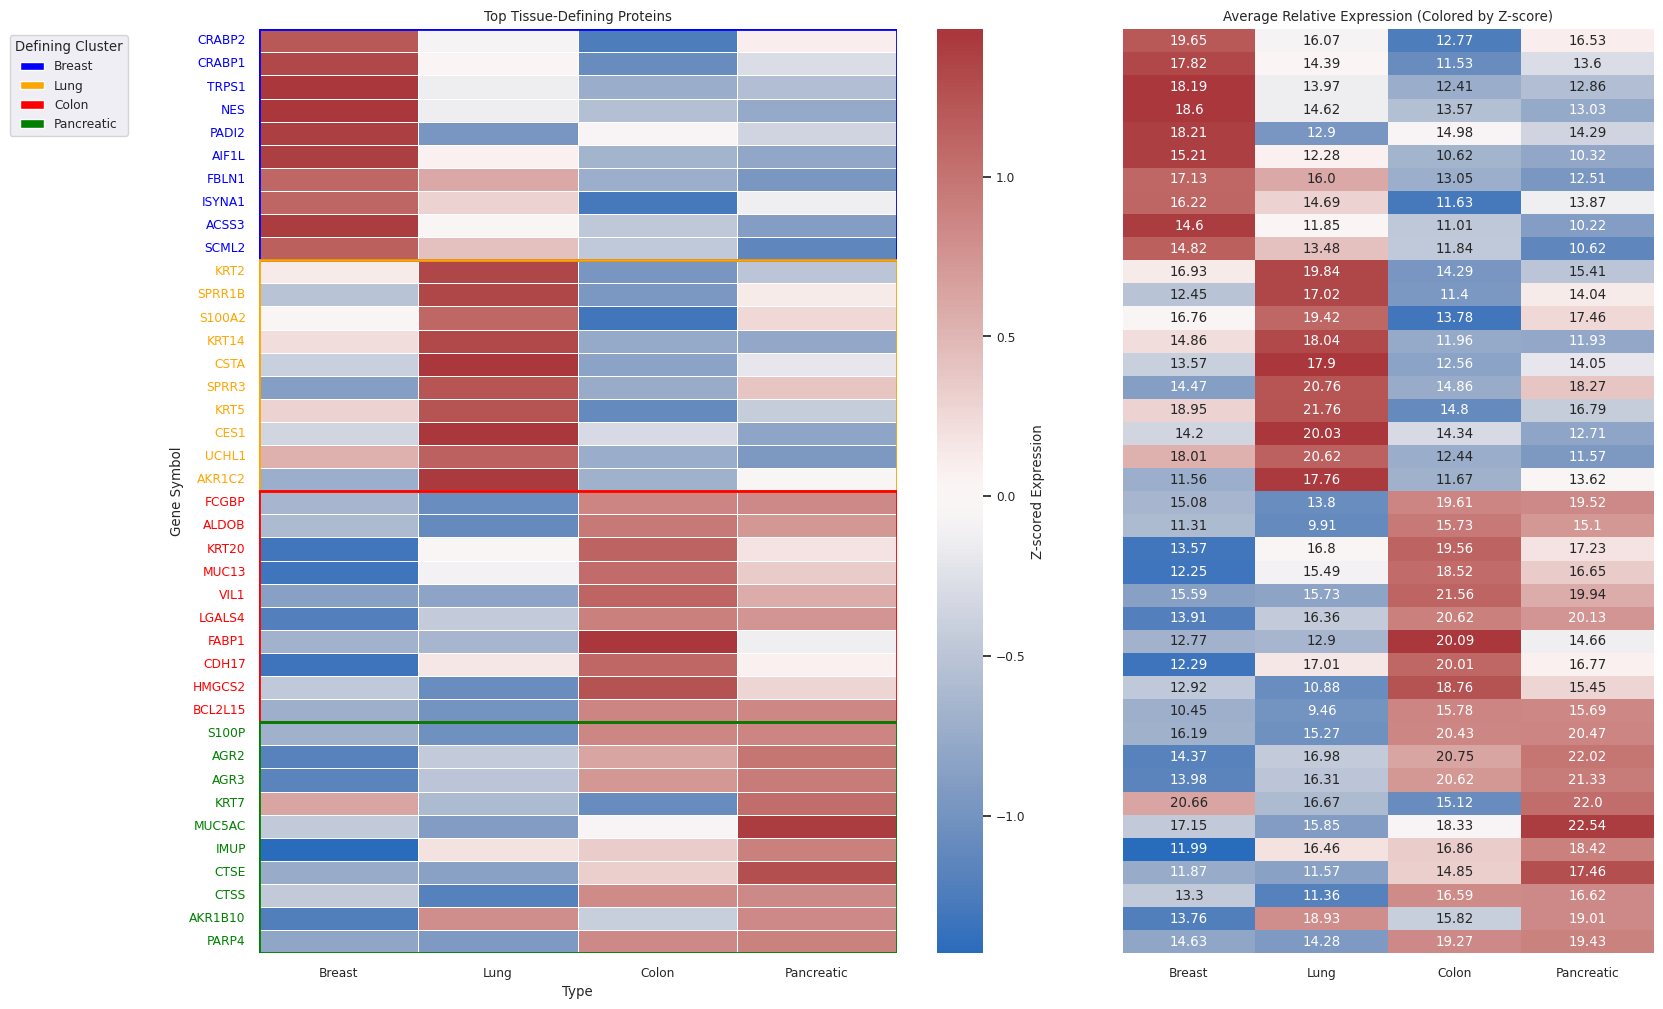

In [64]:
import pandas as pd
import numpy as np
from scipy.stats import f_oneway
from statsmodels.stats.multitest import multipletests
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.patches as patches

# --- Step 0. Define clusters ---
all_clusters = ['Breast', 'Lung', 'Colon', 'Pancreatic']  

# --- Step 1. Collect sample IDs per cluster ---
cluster_samples = {
    c: metadata_avg_indexed.loc[metadata_avg_indexed["Type"] == c, "Sample_ID"].tolist()
    for c in all_clusters
}

# --- Step 2. Compute cluster averages ---
cluster_means = pd.DataFrame({
    c: expr_avg_filt[cluster_samples[c]].mean(axis=1)
    for c in all_clusters
})


# --- Step 3. Run ANOVA across all clusters ---
anova_results = []
for protein in expr_avg_filt.index:
    values = [expr_avg_filt.loc[protein, cluster_samples[c]] for c in all_clusters]
    f_val, p_val = f_oneway(*values)
    anova_results.append((protein, f_val, p_val))

anova_df = pd.DataFrame(anova_results, columns=["Protein_ID", "F_value", "p_value"])

# --- Step 4. Add multiple testing correction (Benjamini–Hochberg FDR) ---
anova_df["p_adj"] = multipletests(anova_df["p_value"], method="fdr_bh")[1]

# --- Step 5. Merge with cluster means and metadata ---
anova_df = anova_df.merge(cluster_means, left_on="Protein_ID", right_index=True)
anova_df = anova_df.merge(metadata[["Protein_ID", "Gene"]], on="Protein_ID", how="left")

# Step 6: Calculate Log2FC
anova_df["Most_Expressed"] = anova_df[['Breast', 'Colon', 'Pancreatic', 'Lung']].idxmax(axis=1)
anova_df["Least_Expressed"] = anova_df[['Breast', 'Colon', 'Pancreatic', 'Lung']].idxmin(axis=1)
anova_df['Greatest_Log2FC'] = anova_df[['Breast', 'Colon', 'Pancreatic', 'Lung']].max(axis=1) - anova_df[['Breast', 'Colon', 'Pancreatic', 'Lung']].min(axis=1)

# --- Step 7. Select top N proteins per defining cluster ---
top_n = 10
top_by_cluster = []
for c in all_clusters:
    sub = anova_df[anova_df["Most_Expressed"] == c].nlargest(top_n, "Greatest_Log2FC")
    sub["Type"] = c
    top_by_cluster.append(sub)

top_genes_df = pd.concat(top_by_cluster)
top_genes_df = top_genes_df.drop_duplicates(subset="Gene")
type_order = ['Breast', 'Lung', 'Colon', 'Pancreatic']
top_genes_df['Type'] = pd.Categorical(top_genes_df['Type'], categories=type_order, ordered=True)
top_genes_df = top_genes_df.sort_values('Type')

top_genes_df

# --- Step 8. Build heatmap data ---
heatmap_data = cluster_means.loc[top_genes_df["Protein_ID"], ['Breast', 'Lung', 'Colon', 'Pancreatic']]
heatmap_data.index = top_genes_df["Gene"]

# --- Step 9. Compute Z-scores across all clusters ---
heatmap_data_z = heatmap_data.sub(heatmap_data.mean(axis=1), axis=0).div(heatmap_data.std(axis=1), axis=0)

# --- Step 10. Define cluster colors ---
cluster_color_map = {'Breast': "blue", 'Lung': "orange", 'Colon': "red", 'Pancreatic': "green"}
row_colors = top_genes_df.set_index("Gene")["Type"].map(cluster_color_map)

# --- Step 11. Plot heatmap + expression table ---
sns.set(font_scale=0.8)
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(1, 2, width_ratios=[3, 2], wspace=0.1)

# Left: Z-scored heatmap
ax0 = fig.add_subplot(gs[0])
sns.heatmap(
    heatmap_data_z,
    cmap="vlag",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Z-scored Expression"},
    ax=ax0,
    yticklabels=True,
    xticklabels=['Breast', 'Lung', 'Colon', 'Pancreatic']
)
ax0.set_title("Top Tissue-Defining Proteins")
ax0.set_xlabel("Type")
ax0.set_ylabel("Gene Symbol")

# Color row labels by defining cluster
for ytick, gene in zip(ax0.get_yticklabels(), heatmap_data_z.index):
    cluster = top_genes_df.set_index("Gene").loc[gene, "Type"]
    ytick.set_color(cluster_color_map[cluster])

# --- Fix: Color expression table by Z-scores but show average values ---
# We re-use the color mapping from heatmap_data_z for coloring
ax1 = fig.add_subplot(gs[1])
sns.heatmap(
    heatmap_data_z,       # use Z-scores for coloring
    annot=heatmap_data.round(2),  # show actual average expression values
    fmt="",               # suppress scientific notation
    cmap="vlag",
    center=0,
    cbar=False,
    yticklabels=False,
    xticklabels=['Breast', 'Lung', 'Colon', 'Pancreatic'],
    ax=ax1
)
ax1.set_title("Average Relative Expression (Colored by Z-score)")
ax1.set_ylabel("")

# --- Step 12. Legend for defining clusters ---
handles = [Patch(facecolor=color, label=c) for c, color in cluster_color_map.items()]
ax0.legend(handles=handles, title="Defining Cluster", loc="upper left", bbox_to_anchor=(-0.4, 1))

# --- Step 13. Bounding boxes for cluster-defining genes (respect ordered tissue list) ---
type_order = ['Breast', 'Lung', 'Colon', 'Pancreatic']

for cluster in type_order:
    color = cluster_color_map[cluster]
    gene_indices = [
        i for i, gene in enumerate(heatmap_data_z.index)
        if top_genes_df.set_index("Gene").loc[gene, "Type"] == cluster
    ]
    if not gene_indices:
        continue
    y_start = min(gene_indices)
    y_end = max(gene_indices) + 1
    rect = patches.Rectangle(
        xy=(0, y_start),
        width=len(type_order),
        height=y_end - y_start,
        fill=False,
        edgecolor=color,
        linewidth=2
    )
    ax0.add_patch(rect)

plt.tight_layout()
plt.savefig("Cluster_Heatmap_ExpressionTable_wLung_L2FC_120325.png", dpi=300, bbox_inches="tight")
plt.savefig("Cluster_Heatmap_ExpressionTable_wLung_L2FC_120325.pdf", bbox_inches="tight")
plt.show()

In [65]:
# --- Step 14. Export ANOVA table ---
anova_df.to_csv("ANOVA_with_FDR_Log2FC_wLung_120325.tsv", sep="\t", index=False)
anova_df

,Protein_ID,F_value,p_value,p_adj,Breast,Lung,Colon,Pancreatic,Gene,Most_Expressed,Least_Expressed,Greatest_Log2FC
0,GLYG,3.489967,2.214926e-02,0.057207,15.466788,15.432717,14.726600,15.942650,GYG1,Pancreatic,Colon,1.216050
1,AL1L2,7.636206,2.607518e-04,0.002222,14.438920,14.698646,12.661103,11.564934,ALDH1L2,Lung,Pancreatic,3.133711
2,FUBP3,1.330421,2.747265e-01,0.367175,18.401964,18.731130,18.516862,18.323507,FUBP3,Lung,Pancreatic,0.407623
3,SNX12,0.229960,8.751047e-01,0.898158,17.245738,17.184875,17.134870,17.259638,SNX12,Pancreatic,Colon,0.124768
4,ARGAL,14.952536,4.147012e-07,0.000017,15.438213,12.217082,16.598070,15.226845,ARHGEF10L,Colon,Lung,4.380987
...,...,...,...,...,...,...,...,...,...,...,...,...
7826,DC2I2,5.337843,2.826146e-03,0.012302,11.619905,10.064539,10.519334,10.242884,DYNC2I2,Breast,Lung,1.555365
7827,CLK2,1.663347,1.865118e-01,0.275944,10.388329,9.734732,9.515847,9.801226,CLK2,Breast,Colon,0.872482
7828,ZBT45,1.338732,2.721020e-01,0.364868,9.766437,9.397192,9.389301,9.666047,ZBTB45,Breast,Colon,0.377136
7829,BUB1,8.046027,1.739625e-04,0.001616,12.495817,11.310922,10.205061,10.917625,BUB1,Breast,Colon,2.290756
